## Should prepare the analysis of the 80k element based data and combine the NGN2 and undiffWTC11 data into one table which can be extended using SCREEN, open-chromatin and other markers

In [1]:
import ast
import pandas as pd
import numpy as np
import yaml

In [2]:
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [3]:
# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

### 1. Data preparation
- from cell-type specific data to combined dataset 
  - undiffWTC11: `undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled`
  - NGN2: `NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled`

In [4]:
undiff_data_raw = pd.read_csv(config['files']['creating']['undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled'], sep="\t", low_memory=False)

# ngn2_data_raw = pd.read_csv(config['files']['creating']['NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled'], sep="\t", low_memory=False)
ngn2_data_raw = pd.read_csv(config['files']['creating']['NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_neuro_ctrl'], sep="\t", low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    undiff_data_raw[col] = undiff_data_raw[col].apply(safe_eval)
    ngn2_data_raw[col] = ngn2_data_raw[col].apply(safe_eval)

undiff_data_raw["not_shifted_bcalm_element_log_ratio_activity"] = undiff_data_raw["bcalm_element_log_ratio_activity"]
undiff_data_raw

,name,sequence,category,class,source,ref,chr,start,end,strand,...,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,not_shifted_bcalm_element_log_ratio_activity
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[234],[NC_000001.11:159752292:A:G],[ref],NaN,1.000000,-0.020025,True,GC_Mohlke,0.020912,-0.020025
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[145],[NC_000001.11:230159168:C:T],[ref],NaN,1.000000,0.023178,True,GC_Mohlke,0.743514,0.023178
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[32, 192]","[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000,0.030124,True,GC_Mohlke,0.859695,0.030124
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[192],[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000,0.008197,True,GC_Mohlke,0.492942,0.008197
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[120],[NC_000001.11:230161389:C:T],[ref],NaN,1.000000,-0.004511,True,GC_Mohlke,0.280399,-0.004511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,None,NaN,1.000000,0.046735,True,GC_Glut_Chengyu,1.137508,0.046735
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,None,NaN,1.000000,0.084739,True,GC_Glut_Chengyu,1.773161,0.084739
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,None,NaN,0.338260,0.097477,True,GC_Glut_Chengyu,1.986196,0.097477
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,None,NaN,0.000374,0.125486,True,GC_Glut_Chengyu,2.454677,0.125486


In [5]:
ngn2_data_raw

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,2.586896e-43,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,8.456762e-05,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,2.705467e-13,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,2.536828e-09,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [ ]:
# scarmbled controls: for iterative design
ngn2_data_raw_scrambled = ngn2_data_raw.loc[ngn2_data_raw['name'].str.contains("scramb")].copy()
ngn2_data_raw_scrambled_tested = ngn2_data_raw_scrambled.loc[ngn2_data_raw_scrambled['bcalm_data_exists']].copy()
ngn2_data_raw_scrambled_tested
output_path_scrambled_controls = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_2025_design_WTC11/results/80k_controls/NGN2_tested_scrambled_controls.metadata.tsv.gz"
writing = False
if writing:
    ngn2_data_raw_scrambled_tested.to_csv(output_path_scrambled_controls, sep="\t", index=False, compression="gzip")

In [11]:
# add label column
def add_label_column(name):
    """Add either scrambled or tested or not_important_for_cell_type_comparison label to the name"""
    if "scramble" in name:
        return "scrambled"
    elif "cardiac_neuro_cava_random" in name:
        return "tested"
    else:
        return "not_important_for_cell_type_comparison"

undiff_data_raw["label"] = undiff_data_raw[col_name].apply(add_label_column)
ngn2_data_raw["label"] = ngn2_data_raw[col_name].apply(add_label_column)

In [12]:
undiff_data_raw.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'not_shifted_bcalm_element_log_ratio_activity'],
      dtype='object')

In [13]:
# check if the names are the same in both dataframes
undiff_names = set(undiff_data_raw[col_name])
ngn2_names = set(ngn2_data_raw[col_name])

# Find common names
common_names = undiff_names.intersection(ngn2_names)
# Find names that are in undiff_data but not in ngn2_data
undiff_only_names = undiff_names - ngn2_names
# Find names that are in ngn2_data but not in undiff_data
ngn2_only_names = ngn2_names - undiff_names
print(f"Number of common names: {len(common_names)}")
print(f"Number of names in undiff_data but not in ngn2_data: {len(undiff_only_names)}")
print(f"Number of names in ngn2_data but not in undiff_data: {len(ngn2_only_names)}")

Number of common names: 80215
Number of names in undiff_data but not in ngn2_data: 0
Number of names in ngn2_data but not in undiff_data: 0


#### Combine datasets into one dataframe

In [14]:
# remove unimportant rows (not_important_for_cell_type_comparison)
undiff_data_raw = undiff_data_raw.loc[undiff_data_raw["label"] != "not_important_for_cell_type_comparison"]
ngn2_data_raw = ngn2_data_raw.loc[ngn2_data_raw["label"] != "not_important_for_cell_type_comparison"]


In [36]:
import pandas as pd
import numpy as np


# --- Step 2: Custom Normalization using Scrambled Controls ---
def apply_custom_scrambled_normalization(df_celltype, raw_activity_col, label_col='label'):
    """
    Normalizes activities using the median and standard deviation of scrambled controls.
    """
    # Identify scrambled sequences using the 'label' column
    scrambled_controls = df_celltype[df_celltype[label_col] == 'scrambled'][raw_activity_col].dropna().copy()

    if scrambled_controls.empty:
        raise ValueError(f"No 'scrambled' value found in '{label_col}' column or no data for '{raw_activity_col}' in scrambled rows.")

    scrambled_median = scrambled_controls.median()
    scrambled_std = scrambled_controls.std()

    if scrambled_std == 0:
        print(f"Warning: Standard deviation of scrambled controls is zero for {raw_activity_col}. Normalization by division will result in NaNs or Inf.")
        # Handle cases where std is 0 (e.g., return raw_activity - median)
        normalized_activities = df_celltype[raw_activity_col] - scrambled_median
    else:
        normalized_activities = (df_celltype[raw_activity_col] - scrambled_median) / scrambled_std

    return normalized_activities, scrambled_median, scrambled_std

print("Performing custom normalization for NGN2...")
ngn2_data_raw['normalized_activity_NGN2'], ngn2_scrambled_median, ngn2_scrambled_std = \
    apply_custom_scrambled_normalization(ngn2_data_raw, 'bcalm_element_log_ratio_activity')
print(f"NGN2 Scrambled Median: {ngn2_scrambled_median:.4f}, Std Dev: {ngn2_scrambled_std:.4f}")

print("Performing custom normalization for undiffWTC11...")
undiff_data_raw['normalized_activity_undiffWTC11'], undiff_scrambled_median, undiff_scrambled_std = \
    apply_custom_scrambled_normalization(undiff_data_raw, 'bcalm_element_log_ratio_activity')
print(f"undiffWTC11 Scrambled Median: {undiff_scrambled_median:.4f}, Std Dev: {undiff_scrambled_std:.4f}")


# --- Step 3: Rename and select essential columns for merging ---
# Keep only relevant columns to avoid redundancy and clarify meaning
cols_to_keep_ngn2 = ['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label', # 'label' now
                     'bcalm_element_log_ratio_activity', 'bcalm_element_adjusted_p_value', # For CRE determination
                     'normalized_activity_NGN2', 'bcalm_data_exists']
df_ngn2_processed = ngn2_data_raw[cols_to_keep_ngn2].copy()
df_ngn2_processed.rename(columns={'bcalm_element_log_ratio_activity': 'raw_activity_NGN2_log2FC_bcalm',
                                   'bcalm_element_adjusted_p_value': 'bcalm_adj_p_NGN2',
                                   'bcalm_data_exists': 'bcalm_data_exists_NGN2'
                                   }, inplace=True)

cols_to_keep_undiff = ['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label', # 'label' now
                       'bcalm_element_log_ratio_activity', 'bcalm_element_adjusted_p_value', # For CRE determination
                       'normalized_activity_undiffWTC11', 'bcalm_data_exists']
df_undiff_processed = undiff_data_raw[cols_to_keep_undiff].copy()
df_undiff_processed.rename(columns={'bcalm_element_log_ratio_activity': 'raw_activity_undiffWTC11_log2FC_bcalm',
                                    'bcalm_element_adjusted_p_value': 'bcalm_adj_p_undiffWTC11',
                                    'bcalm_data_exists': 'bcalm_data_exists_undiffWTC11',
                                    }, inplace=True)

import re

def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found

# df_undiff_processed['SCREEN_ID'] = df_undiff_processed["name"].apply(extract_eh38e_number)
# df_ngn2_processed['SCREEN_ID'] = df_ngn2_processed["name"].apply(extract_eh38e_number)


# --- Step 4: Merge the processed dataframes into a single master DataFrame ---
# Use 'outer' merge to keep all elements that were measured in at least one cell type.
# This will result in NaNs for elements not measured in a specific cell type.
df_elements = pd.merge(
    df_ngn2_processed,
    df_undiff_processed,
    on=['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label'], # Using 'label' now
    how='outer',
    suffixes=('_NGN2', '_undiffWTC11') # Avoid suffixing common columns
)

# focus on the tested sequences
df_elements = df_elements.loc[df_elements["label"] == "tested"]

# add SCREEN_ID
df_elements['SCREEN_ID'] = df_elements["name"].apply(extract_eh38e_number)
df_elements

def add_SCREEN_CRE_info(df, config_info="npc_screen_active_cre", new_name="is_NPC_SCREEN_cCRE", screen_id_col="SCREEN_ID"):
    """Read cre bed and add if the given SCREEN_ID is a CRE within the provided bed file or not"""
    # read given file
    screen_regions = pd.read_csv(config["files"]["creating"][config_info],sep="\t")
    screen_regions.columns = ["chr", "start", "end", screen_id_col, "score", "strand", "second_start", "second_end", "intensity", "annotation", "info"]

    # add true as column
    screen_regions[new_name] = True

    # left join
    df = df.merge(screen_regions[[screen_id_col, new_name]], on=screen_id_col, how="left").copy()

    df[new_name] = df[new_name].astype('boolean')
    # set na to false
    df[new_name] = df[new_name].fillna(False)
    return df.copy()

df_elements = add_SCREEN_CRE_info(df_elements, config_info="npc_screen_active_cre", new_name="is_NPC_SCREEN_cCRE", screen_id_col="SCREEN_ID")
# df_elements = add_SCREEN_CRE_info(df_elements, config_info="WTC11_screen_active_cre", new_name="is_WTC11_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_info(df_elements, config_info="H9_screen_active_cre", new_name="is_H9_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_info(df_elements, config_info="H1_screen_active_cre", new_name="is_H1_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_info(df_elements, config_info="neural_stem_cell_screen_active_cre", new_name="is_neural_stem_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_info(df_elements, config_info="gluta_screen_active_cre", new_name="is_excitatory_neuron_SCREEN_cCRE", screen_id_col="SCREEN_ID")


# add the annotation for the CRE from the SCREEN file:
def add_SCREEN_CRE_annotation_group_info(df, config_info="npc_screen_active_cre", new_name="is_NPC_SCREEN_cCRE", screen_id_col="SCREEN_ID"):
    """Read cre bed and add if the given SCREEN_ID is a CRE within the provided bed file or not the provided annotation group will be boolean value in a new column:
    e.g. is_NPC_SCREEN_pELS: True if yes or no if not
    """
    # read given file
    screen_regions = pd.read_csv(config["files"]["creating"][config_info],sep="\t")
    screen_regions.columns = ["chr", "start", "end", screen_id_col, "score", "strand", "second_start", "second_end", "intensity", "annotation", "info"]
    for name in screen_regions["annotation"].unique():
        # filter the screen regions table down and add the information to the table
        screen_regions_group = screen_regions[screen_regions["annotation"] == name].copy()
        new_col_name = f"{name}_{new_name}"
        screen_regions_group[new_col_name] = True
        # merge the group information into the main DataFrame
        df = df.merge(screen_regions_group[[screen_id_col, new_col_name]], on=screen_id_col, how="left").copy()
        df[new_col_name] = df[new_col_name].astype('boolean')
        # set na to false
        df[new_col_name] = df[new_col_name].fillna(False)

    return df.copy()

df_elements = add_SCREEN_CRE_annotation_group_info(df_elements, config_info="npc_screen_active_cre", new_name="is_NPC_SCREEN_cCRE", screen_id_col="SCREEN_ID")
# df_elements = add_SCREEN_CRE_annotation_group_info(df_elements, config_info="WTC11_screen_active_cre", new_name="is_WTC11_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_annotation_group_info(df_elements, config_info="H9_screen_active_cre", new_name="is_H9_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_annotation_group_info(df_elements, config_info="H1_screen_active_cre", new_name="is_H1_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_annotation_group_info(df_elements, config_info="neural_stem_cell_screen_active_cre", new_name="is_neural_stem_SCREEN_cCRE", screen_id_col="SCREEN_ID")
df_elements = add_SCREEN_CRE_annotation_group_info(df_elements, config_info="gluta_screen_active_cre", new_name="is_excitatory_neuron_SCREEN_cCRE", screen_id_col="SCREEN_ID")

# --- Step 5: Add derived columns based on BCalm results for CRE status and Effect classification ---
# Define CRE based on BCalm criteria (e.g., adj_p_value < 0.05 and activity > 0)
# You might need to adjust these thresholds based on BCalm's documentation or your desired stringency.
P_VALUE_THRESHOLD = 0.05
ACTIVITY_THRESHOLD = 0 # For log2FC, activity > 0 means increasing


df_elements['is_dCRE_NGN2'] = (df_elements['bcalm_adj_p_NGN2'] < P_VALUE_THRESHOLD)

df_elements['is_dCRE_undiffWTC11'] = (df_elements['bcalm_adj_p_undiffWTC11'] < P_VALUE_THRESHOLD)

# Define bcalm_effect_X categories
def classify_bcalm_effect(p_value, log_ratio_activity, p_threshold=P_VALUE_THRESHOLD):
    if pd.isna(p_value) or pd.isna(log_ratio_activity):
        return np.nan # Or a specific 'not_measured' category
    if p_value < p_threshold:
        if log_ratio_activity > 0:
            return 'increasing'
        elif log_ratio_activity < 0:
            return 'decreasing'
        else: # log_ratio_activity == 0, but p-value significant (rare but possible)
            return 'no_effect' # Or a specific 'significant_zero'
    else:
        return 'no_effect'

df_elements['bcalm_effect_NGN2'] = df_elements.apply(
    lambda row: classify_bcalm_effect(row['bcalm_adj_p_NGN2'], row['normalized_activity_NGN2']), axis=1
)
df_elements['bcalm_effect_undiffWTC11'] = df_elements.apply(
    lambda row: classify_bcalm_effect(row['bcalm_adj_p_undiffWTC11'], row['normalized_activity_undiffWTC11']), axis=1
)

# # Ensure 'bcalm_effect_X' columns are categorical for efficiency
df_elements['bcalm_effect_NGN2'] = df_elements['bcalm_effect_NGN2'].astype('category')
df_elements['bcalm_effect_undiffWTC11'] = df_elements['bcalm_effect_undiffWTC11'].astype('category')


# --- Step 6: Add measured_in_both_celltypes column ---
# An element is measured in both if its raw activity is not NaN in both cell types
df_elements['measured_in_both_celltypes'] = \
    df_elements['raw_activity_NGN2_log2FC_bcalm'].notna() & \
    df_elements['raw_activity_undiffWTC11_log2FC_bcalm'].notna()

# --- Step 7: (Future) Add Overlap Annotations (Open Chromatin, ReMap2022) ---
# This typically involves external tools like pyranges or pybedtools
# For example, to add 'overlaps_open_chromatin_NGN2':
# Load your NGN2 open chromatin BED file
# Convert df_elements to a pyranges object (filtered for non-scrambled elements)
# Perform overlap and merge boolean results back to df_elements.
# This will be detailed in a subsequent step-by-step guide.

# # Example of how the first few rows of your df_elements might look:
# print("\nFirst 5 rows of df_elements:")
# print(df_elements.head())
# print("\nDataFrame Info:")
# df_elements.info()

Performing custom normalization for NGN2...
NGN2 Scrambled Median: -0.0152, Std Dev: 0.0387
Performing custom normalization for undiffWTC11...
undiffWTC11 Scrambled Median: -0.0213, Std Dev: 0.0598


/tmp/ipykernel_354845/1124578293.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ngn2_data_raw['normalized_activity_NGN2'], ngn2_scrambled_median, ngn2_scrambled_std = \
/tmp/ipykernel_354845/1124578293.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  undiff_data_raw['normalized_activity_undiffWTC11'], undiff_scrambled_median, undiff_scrambled_std = \


In [50]:
# Ensure boolean columns are actual bool Dtype to prevent future warnings
for col in df_elements.columns:
    if col.startswith('is_'):
        df_elements[col] = df_elements[col].astype(bool)

In [51]:
df_elements

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,PLS_is_excitatory_neuron_SCREEN_cCRE,pELS_is_excitatory_neuron_SCREEN_cCRE,CA-H3K4me3_is_excitatory_neuron_SCREEN_cCRE,CA-only_is_excitatory_neuron_SCREEN_cCRE,CA-TF_is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,1.000000e+00,-1.928542,...,False,False,False,False,False,False,False,no_effect,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149.0,70277419.0,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116.0,107008386.0,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,1.641708e-32,3.966275,...,False,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,2.456195e-04,1.804262,...,False,False,False,False,False,True,False,increasing,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939.0,107039209.0,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,False,False,False,False,False,no_effect,no_effect,True


In [52]:
df_elements.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'PLS_is_NPC_SCREEN_cCRE',
       'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
       'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
       'dELS_is_NPC_SCREEN_cCRE', 'PLS_is_H9_SCREEN_cCRE',
       'CA-only_is_H9_SCREEN_cCRE', 'CA-H3K4me3_is_H9_SCREEN_cCRE',
       'pELS_is_H9_SCREEN_cCRE', 'dELS_is_H9_SCREEN_cCRE',
       'CA-TF_is_H9_SCREEN_cCRE', 'PLS_is_H1_SCREEN_cCRE',
       'CA-TF_is_H1_SCREEN_cCRE', 'CA-H3K4me3_is_H1_SCREEN_cCRE',
       'CA-only_is_H1_SCRE

#### Check the normalized activities

<Axes: >

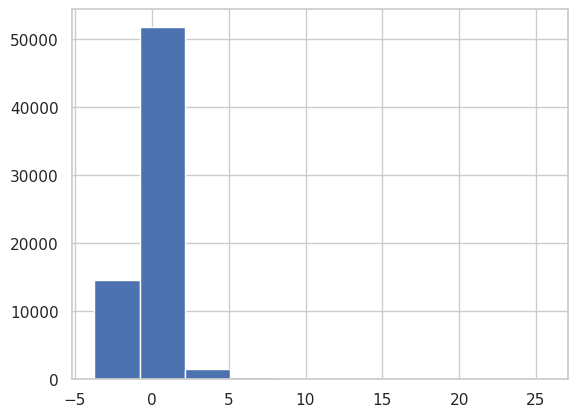

In [53]:
df_elements['normalized_activity_NGN2'].hist()

<Axes: >

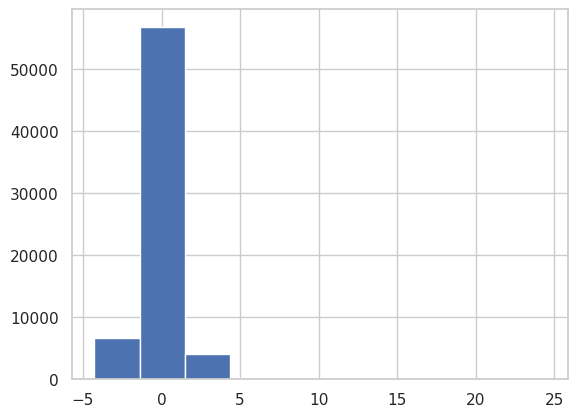

In [40]:
df_elements['normalized_activity_undiffWTC11'].hist()

##### Investigate SCREEN columns 

In [42]:
screen_columns = ['is_NPC_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE']
screen_columns = ['is_NPC_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE', 'is_excitatory_neuron_SCREEN_cCRE']

for col in screen_columns:
    print(df_elements[col].value_counts())

is_NPC_SCREEN_cCRE
False    69810
True      4130
Name: count, dtype: Int64
is_H9_SCREEN_cCRE
False    70723
True      3217
Name: count, dtype: Int64
is_H1_SCREEN_cCRE
False    70841
True      3099
Name: count, dtype: Int64
is_neural_stem_SCREEN_cCRE
False    69352
True      4588
Name: count, dtype: Int64
is_excitatory_neuron_SCREEN_cCRE
False    72127
True      1813
Name: count, dtype: Int64


In [43]:
df_elements["measured_in_both_celltypes"].value_counts()

measured_in_both_celltypes
True     67451
False     6489
Name: count, dtype: int64

In [23]:
df_elements["is_dCRE_NGN2"].value_counts()

is_dCRE_NGN2
False    65475
True      8465
Name: count, dtype: int64

In [24]:
df_elements["is_dCRE_undiffWTC11"].value_counts()

is_dCRE_undiffWTC11
False    73514
True       426
Name: count, dtype: int64

In [25]:
df_elements["bcalm_effect_NGN2"].value_counts()

bcalm_effect_NGN2
no_effect     59776
increasing     8465
Name: count, dtype: int64

In [26]:
df_elements["bcalm_effect_undiffWTC11"].value_counts()

bcalm_effect_undiffWTC11
no_effect     67080
increasing      393
decreasing       33
Name: count, dtype: int64

In [44]:
df_elements.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE',
       'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'PLS_is_NPC_SCREEN_cCRE',
       'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
       'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
       'dELS_is_NPC_SCREEN_cCRE', 'PLS_is_H9_SCREEN_cCRE',
       'CA-only_is_H9_SCREEN_cCRE', 'CA-H3K4me3_is_H9_SCREEN_cCRE',
       'pELS_is_H9_SCREEN_cCRE', 'dELS_is_H9_SCREEN_cCRE',
       'CA-TF_is_H9_SCREEN_cCRE', 'PLS_is_H1_SCREEN_cCRE',
       'CA-TF_is_H1_SCREEN_cCRE', 'CA-H3K4me3_is_H1_SCREEN_cCRE',
       'CA-only_is_H1_SCRE

In [45]:
# iterate over one of the annotations with the groups:
columns_of_interst = ['PLS_is_NPC_SCREEN_cCRE',
'CA-only_is_NPC_SCREEN_cCRE', 'CA-H3K4me3_is_NPC_SCREEN_cCRE',
'CA-TF_is_NPC_SCREEN_cCRE', 'pELS_is_NPC_SCREEN_cCRE',
'dELS_is_NPC_SCREEN_cCRE']

col_name = 'is_NPC_SCREEN_cCRE'
print(f"{col_name}: {df_elements[col_name].value_counts()}")
print(f"Percentage of True: {df_elements[col_name].mean() * 100:.2f}%")
print(f"Percentage of False: {(1 - df_elements[col_name].mean()) * 100:.2f}%")
print("\n")  # Add a newline for better readability
for col in columns_of_interst:
    print(f"{col}: {df_elements[col].value_counts()}")
    print(f"Percentage of True: {df_elements[col].mean() * 100:.2f}%")
    print(f"Percentage of False: {(1 - df_elements[col].mean()) * 100:.2f}%")
    print("\n")  # Add a newline for better readability


is_NPC_SCREEN_cCRE: is_NPC_SCREEN_cCRE
False    69810
True      4130
Name: count, dtype: Int64
Percentage of True: 5.59%
Percentage of False: 94.41%


PLS_is_NPC_SCREEN_cCRE: PLS_is_NPC_SCREEN_cCRE
False    73851
True        89
Name: count, dtype: Int64
Percentage of True: 0.12%
Percentage of False: 99.88%


CA-only_is_NPC_SCREEN_cCRE: CA-only_is_NPC_SCREEN_cCRE
False    72801
True      1139
Name: count, dtype: Int64
Percentage of True: 1.54%
Percentage of False: 98.46%


CA-H3K4me3_is_NPC_SCREEN_cCRE: CA-H3K4me3_is_NPC_SCREEN_cCRE
False    73165
True       775
Name: count, dtype: Int64
Percentage of True: 1.05%
Percentage of False: 98.95%


CA-TF_is_NPC_SCREEN_cCRE: CA-TF_is_NPC_SCREEN_cCRE
False    73803
True       137
Name: count, dtype: Int64
Percentage of True: 0.19%
Percentage of False: 99.81%


pELS_is_NPC_SCREEN_cCRE: pELS_is_NPC_SCREEN_cCRE
False    73377
True       563
Name: count, dtype: Int64
Percentage of True: 0.76%
Percentage of False: 99.24%


dELS_is_NPC_SCREEN_cCRE: d

In [46]:
[col for col in df_elements.columns if "is_WTC11_SCREEN_cCRE" in col]

[]

In [47]:
cell_type_mappings = {
    'NPC': {
        'main_col': 'is_NPC_SCREEN_cCRE',
        'epigenetic_cols': [
            'PLS_is_NPC_SCREEN_cCRE',
            'CA-only_is_NPC_SCREEN_cCRE',
            'CA-H3K4me3_is_NPC_SCREEN_cCRE',
            'CA-TF_is_NPC_SCREEN_cCRE',
            'pELS_is_NPC_SCREEN_cCRE',
            'dELS_is_NPC_SCREEN_cCRE'
        ]
    },
    'H9': {
        'main_col': 'is_H9_SCREEN_cCRE',
        'epigenetic_cols': [
            'PLS_is_H9_SCREEN_cCRE',
            'CA-only_is_H9_SCREEN_cCRE',
            'CA-H3K4me3_is_H9_SCREEN_cCRE',
            'pELS_is_H9_SCREEN_cCRE',
            'dELS_is_H9_SCREEN_cCRE',
            'CA-TF_is_H9_SCREEN_cCRE'
        ]
    },
    'H1': {
        'main_col': 'is_H1_SCREEN_cCRE',
        'epigenetic_cols': [
            'PLS_is_H1_SCREEN_cCRE',
            'CA-TF_is_H1_SCREEN_cCRE',
            'CA-H3K4me3_is_H1_SCREEN_cCRE',
            'CA-only_is_H1_SCREEN_cCRE',
            'pELS_is_H1_SCREEN_cCRE',
            'dELS_is_H1_SCREEN_cCRE'
        ]
    },
    'neural_stem': {
        'main_col': 'is_neural_stem_SCREEN_cCRE',
        'epigenetic_cols': [
            'PLS_is_neural_stem_SCREEN_cCRE',
            'CA-only_is_neural_stem_SCREEN_cCRE',
            'CA-H3K4me3_is_neural_stem_SCREEN_cCRE',
            'pELS_is_neural_stem_SCREEN_cCRE',
            'dELS_is_neural_stem_SCREEN_cCRE'
        ]
    },
    'excitatory_neuron': {
        'main_col': 'is_excitatory_neuron_SCREEN_cCRE',
        'epigenetic_cols': [
            'dELS_is_excitatory_neuron_SCREEN_cCRE',
            'PLS_is_excitatory_neuron_SCREEN_cCRE',
            'pELS_is_excitatory_neuron_SCREEN_cCRE',
            'CA-H3K4me3_is_excitatory_neuron_SCREEN_cCRE',
            'CA-only_is_excitatory_neuron_SCREEN_cCRE',
            'CA-TF_is_excitatory_neuron_SCREEN_cCRE'
        ]
    }
}

In [48]:
# 2. Process data for plotting
plot_data = [] # To store data for the stacked bar plot

for cell_type_name, ct_info in cell_type_mappings.items():
    main_col = ct_info['main_col']
    epigenetic_cols = ct_info['epigenetic_cols']

    # Filter sequences where the main cell type cCRE is True
    # Using .copy() to prevent SettingWithCopyWarning
    filtered_df_elements = df_elements[df_elements[main_col]].copy()

    total_sequences_for_cell_type = len(filtered_df_elements)

    if total_sequences_for_cell_type == 0:
        print(f"Warning: No sequences found for '{cell_type_name}' (where '{main_col}' is True). Skipping this cell type.")
        continue

    # Calculate proportions for each epigenetic mark
    for ep_col in epigenetic_cols:
        # Extract the concise epigenetic mark name (e.g., 'PLS', 'CA-only')
        # This assumes the format 'MARK_is_CELLTYPE_SCREEN_cCRE' or 'MARK-sub_is_CELLTYPE_SCREEN_cCRE'
        ep_mark_type = ep_col.split('_is_')[0]

        # Calculate the count of True values for this epigenetic mark within the filtered_df_elements
        count_true = filtered_df_elements[ep_col].sum()
        proportion = count_true / total_sequences_for_cell_type

        plot_data.append({
            'Cell Type': cell_type_name,
            'Epigenetic Mark': ep_mark_type,
            'Proportion': proportion,
            'Total Sequences': total_sequences_for_cell_type
        })

# Convert the processed data into a DataFrame suitable for seaborn
plot_df_elements = pd.DataFrame(plot_data)

print("\n--- Processed Data for Plotting Head ---")
print(plot_df_elements.head())


--- Processed Data for Plotting Head ---
  Cell Type Epigenetic Mark  Proportion  Total Sequences
0       NPC             PLS    0.021550             4130
1       NPC         CA-only    0.275787             4130
2       NPC      CA-H3K4me3    0.187651             4130
3       NPC           CA-TF    0.033172             4130
4       NPC            pELS    0.136320             4130


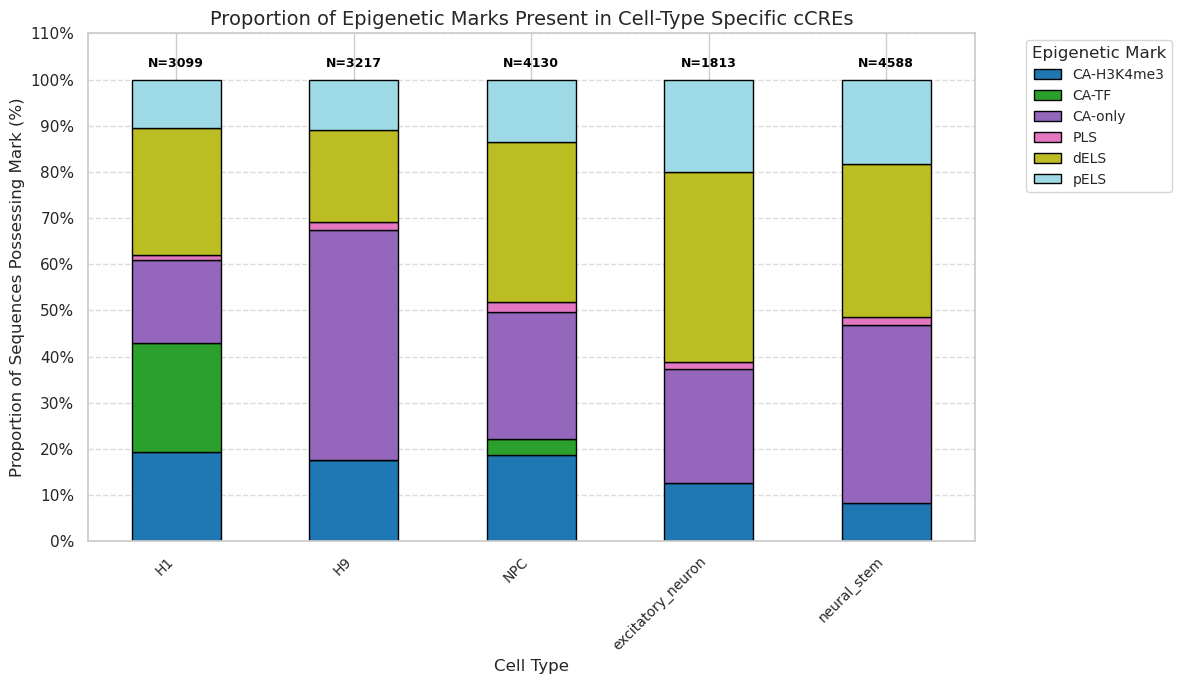

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Create the Stacked Bar Plot
plt.figure(figsize=(12, 7)) # Adjust figure size as needed
sns.set_theme(style="whitegrid")

# Pivot the data to get 'Cell Type' as index, 'Epigenetic Mark' as columns, and 'Proportion' as values
plot_df_elements_pivot = plot_df_elements.pivot_table(
    index='Cell Type',
    columns='Epigenetic Mark',
    values='Proportion'
).fillna(0) # Fill NaN with 0, in case a mark is genuinely absent for a cell type

# Get all unique epigenetic marks for consistent coloring and legend order
all_ep_marks_sorted = sorted(plot_df_elements['Epigenetic Mark'].unique())
# Reorder columns to ensure consistent stacking order across bars
plot_df_elements_pivot = plot_df_elements_pivot[all_ep_marks_sorted]

# Get the total sequences for annotations (for each cell type)
total_sequences_map = plot_df_elements.set_index('Cell Type')['Total Sequences'].drop_duplicates().to_dict()

# Create the stacked bar plot
ax = plot_df_elements_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='tab20', # Use a colormap that provides distinct colors
    edgecolor='black',
    ax=plt.gca() # Use the current figure's axes
)

# Add annotations for total sequences (N=count) above each bar
for i, cell_type in enumerate(plot_df_elements_pivot.index):
    total = total_sequences_map.get(cell_type, 0)
    # Position the text slightly above the bar (y=1.02 for normalized proportion)
    ax.text(i, 1.02, f'N={total}', ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.title('Proportion of Epigenetic Marks Present in Cell-Type Specific cCREs', fontsize=14)
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Proportion of Sequences Possessing Mark (%)', fontsize=12)
# Format y-axis ticks as percentages
plt.yticks(np.arange(0, ax.get_ylim()[1] + 0.1, 0.1), [f'{int(x*100)}%' for x in np.arange(0, ax.get_ylim()[1] + 0.1, 0.1)])
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels for readability
plt.legend(title='Epigenetic Mark', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a subtle y-grid for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Generate a neuron combined column

In [55]:
df_elements['is_npc_or_excitatory_SCREEN_cre'] = df_elements['is_excitatory_neuron_SCREEN_cCRE'] | df_elements['is_NPC_SCREEN_cCRE']
df_elements['is_npc_or_NSC_SCREEN_cre'] = df_elements['is_neural_stem_SCREEN_cCRE'] | df_elements['is_NPC_SCREEN_cCRE']
df_elements['is_npc_or_excitatory_NSC_SCREEN_cre'] = df_elements['is_excitatory_neuron_SCREEN_cCRE'] | df_elements['is_NPC_SCREEN_cCRE'] | df_elements['is_neural_stem_SCREEN_cCRE']
df_elements['is_excitatory_or_NSC_SCREEN_cre'] = df_elements['is_excitatory_neuron_SCREEN_cCRE'] | df_elements['is_neural_stem_SCREEN_cCRE']
df_elements['is_npc_or_excitatory_NSC_SCREEN_cre'].value_counts()

# changed: is_npc_or_excitatory_SCREEN_cre => is_npc_or_excitatory_NSC_SCREEN_cre because I added the information of neural stem SCREEN

is_npc_or_excitatory_NSC_SCREEN_cre
False    67386
True      6554
Name: count, dtype: int64

#### How well does the SCREEN cCRE in this cell-type predict the actual value of sequences being active
- Check the jaccard coefficient
- Confusion matrix: 
                is significant active     not significant active
cCRE SCREEN
not cCRE screen 

In [ ]:
# TODO

####  Is the activity distribution ("raw_activity_NGN2_log2FC_bcalm") of the group defined by "is_NPC_SCREEN_cCRE" compared to the other sequences significantly higher?

In [27]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [28]:
print("\n--- Question 1: NGN2 Activity in is_NPC_SCREEN_cCRE vs. Others ---")
df_elements_ngn2_focus = df_elements.loc[df_elements['bcalm_data_exists_NGN2']].copy()
group_a_q1 = df_elements_ngn2_focus[df_elements_ngn2_focus['is_NPC_SCREEN_cCRE']]['raw_activity_NGN2_log2FC_bcalm']
group_b_q1 = df_elements_ngn2_focus[~df_elements_ngn2_focus['is_NPC_SCREEN_cCRE']]['raw_activity_NGN2_log2FC_bcalm']

# Check group sizes
print(f"Group 'is_NPC_SCREEN_cCRE' size: {len(group_a_q1)}")
print(f"Group 'Others' size: {len(group_b_q1)}")

if len(group_a_q1) > 1 and len(group_b_q1) > 1: # Mann-Whitney requires at least 2 samples per group
    u_stat_q1, p_val_q1 = stats.mannwhitneyu(group_a_q1, group_b_q1, alternative='greater')
    print(f"Mann-Whitney U Statistic: {u_stat_q1:.2f}")
    print(f"P-value: {p_val_q1:.3e}") # Using scientific notation for small p-values

    if p_val_q1 < 0.05: # Common significance threshold
        print(f"Conclusion: Activity in 'is_NPC_SCREEN_cCRE' group is significantly higher (p < 0.05).")
    else:
        print(f"Conclusion: No significant difference or higher activity detected (p >= 0.05).")
    print(f"Median activity for 'is_NPC_SCREEN_cCRE': {group_a_q1.median().round(3)}")
    print(f"Median activity for 'Others': {group_b_q1.median().round(3)}")
else:
    print("Not enough data in one or both groups for statistical testing.")



--- Question 1: NGN2 Activity in is_NPC_SCREEN_cCRE vs. Others ---
Group 'is_NPC_SCREEN_cCRE' size: 3298
Group 'Others' size: 64943
Mann-Whitney U Statistic: 122668389.00
P-value: 1.544e-45
Conclusion: Activity in 'is_NPC_SCREEN_cCRE' group is significantly higher (p < 0.05).
Median activity for 'is_NPC_SCREEN_cCRE': -0.002
Median activity for 'Others': -0.01


#### What about the more close glutamateric neurons / excitatory neurons: 


In [29]:
print("\n--- Question 1: NGN2 Activity in is_excitatory_neuron_SCREEN_cCRE vs. Others ---")
df_elements_ngn2_focus = df_elements.loc[df_elements['bcalm_data_exists_NGN2']].copy()
group_a_q1 = df_elements_ngn2_focus[df_elements_ngn2_focus['is_excitatory_neuron_SCREEN_cCRE']]['raw_activity_NGN2_log2FC_bcalm']
group_b_q1 = df_elements_ngn2_focus[~df_elements_ngn2_focus['is_excitatory_neuron_SCREEN_cCRE']]['raw_activity_NGN2_log2FC_bcalm']

# Check group sizes
print(f"Group 'is_excitatory_neuron_SCREEN_cCRE' size: {len(group_a_q1)}")
print(f"Group 'Others' size: {len(group_b_q1)}")

if len(group_a_q1) > 1 and len(group_b_q1) > 1: # Mann-Whitney requires at least 2 samples per group
    u_stat_q1, p_val_q1 = stats.mannwhitneyu(group_a_q1, group_b_q1, alternative='greater')
    print(f"Mann-Whitney U Statistic: {u_stat_q1:.2f}")
    print(f"P-value: {p_val_q1:.3e}") # Using scientific notation for small p-values

    if p_val_q1 < 0.05: # Common significance threshold
        print(f"Conclusion: Activity in 'is_excitatory_neuron_SCREEN_cCRE' group is significantly higher (p < 0.05).")
    else:
        print(f"Conclusion: No significant difference or higher activity detected (p >= 0.05).")
    print(f"Median activity for 'is_excitatory_neuron_SCREEN_cCRE': {group_a_q1.median().round(3)}")
    print(f"Median activity for 'Others': {group_b_q1.median().round(3)}")
else:
    print("Not enough data in one or both groups for statistical testing.")



--- Question 1: NGN2 Activity in is_excitatory_neuron_SCREEN_cCRE vs. Others ---
Group 'is_excitatory_neuron_SCREEN_cCRE' size: 1105
Group 'Others' size: 67136
Mann-Whitney U Statistic: 43270265.00
P-value: 9.440e-22
Conclusion: Activity in 'is_excitatory_neuron_SCREEN_cCRE' group is significantly higher (p < 0.05).
Median activity for 'is_excitatory_neuron_SCREEN_cCRE': -0.003
Median activity for 'Others': -0.01


#### What about combined: 


In [30]:
print("\n--- Question 1: NGN2 Activity in is_npc_or_excitatory_SCREEN_cre vs. Others ---")
df_elements_ngn2_focus = df_elements.loc[df_elements['bcalm_data_exists_NGN2']].copy()
group_a_q1 = df_elements_ngn2_focus[df_elements_ngn2_focus['is_npc_or_excitatory_SCREEN_cre']]['raw_activity_NGN2_log2FC_bcalm']
group_b_q1 = df_elements_ngn2_focus[~df_elements_ngn2_focus['is_npc_or_excitatory_SCREEN_cre']]['raw_activity_NGN2_log2FC_bcalm']

# Check group sizes
print(f"Group 'is_npc_or_excitatory_SCREEN_cre' size: {len(group_a_q1)}")
print(f"Group 'Others' size: {len(group_b_q1)}")

if len(group_a_q1) > 1 and len(group_b_q1) > 1: # Mann-Whitney requires at least 2 samples per group
    u_stat_q1, p_val_q1 = stats.mannwhitneyu(group_a_q1, group_b_q1, alternative='greater')
    print(f"Mann-Whitney U Statistic: {u_stat_q1:.2f}")
    print(f"P-value: {p_val_q1:.3e}") # Using scientific notation for small p-values

    if p_val_q1 < 0.05: # Common significance threshold
        print(f"Conclusion: Activity in 'is_npc_or_excitatory_SCREEN_cre' group is significantly higher (p < 0.05).")
    else:
        print(f"Conclusion: No significant difference or higher activity detected (p >= 0.05).")
    print(f"Median activity for 'is_npc_or_excitatory_SCREEN_cre': {group_a_q1.median().round(3)}")
    print(f"Median activity for 'Others': {group_b_q1.median().round(3)}")
else:
    print("Not enough data in one or both groups for statistical testing.")



--- Question 1: NGN2 Activity in is_npc_or_excitatory_SCREEN_cre vs. Others ---
Group 'is_npc_or_excitatory_SCREEN_cre' size: 3981
Group 'Others' size: 64260
Mann-Whitney U Statistic: 146519706.00
P-value: 5.192e-54
Conclusion: Activity in 'is_npc_or_excitatory_SCREEN_cre' group is significantly higher (p < 0.05).
Median activity for 'is_npc_or_excitatory_SCREEN_cre': -0.003
Median activity for 'Others': -0.01


In [31]:
print("\n--- Question 1: NGN2 Activity in is_npc_or_excitatory_NSC_SCREEN_cre vs. Others ---")
df_elements_ngn2_focus = df_elements.loc[df_elements['bcalm_data_exists_NGN2']].copy()
group_a_q1 = df_elements_ngn2_focus[df_elements_ngn2_focus['is_npc_or_excitatory_NSC_SCREEN_cre']]['raw_activity_NGN2_log2FC_bcalm']
group_b_q1 = df_elements_ngn2_focus[~df_elements_ngn2_focus['is_npc_or_excitatory_NSC_SCREEN_cre']]['raw_activity_NGN2_log2FC_bcalm']

# Check group sizes
print(f"Group 'is_npc_or_excitatory_NSC_SCREEN_cre' size: {len(group_a_q1)}")
print(f"Group 'Others' size: {len(group_b_q1)}")

if len(group_a_q1) > 1 and len(group_b_q1) > 1: # Mann-Whitney requires at least 2 samples per group
    u_stat_q1, p_val_q1 = stats.mannwhitneyu(group_a_q1, group_b_q1, alternative='greater')
    print(f"Mann-Whitney U Statistic: {u_stat_q1:.2f}")
    print(f"P-value: {p_val_q1:.3e}") # Using scientific notation for small p-values

    if p_val_q1 < 0.05: # Common significance threshold
        print(f"Conclusion: Activity in 'is_npc_or_excitatory_NSC_SCREEN_cre' group is significantly higher (p < 0.05).")
    else:
        print(f"Conclusion: No significant difference or higher activity detected (p >= 0.05).")
    print(f"Median activity for 'is_npc_or_excitatory_NSC_SCREEN_cre': {group_a_q1.median().round(3)}")
    print(f"Median activity for 'Others': {group_b_q1.median().round(3)}")
else:
    print("Not enough data in one or both groups for statistical testing.")



--- Question 1: NGN2 Activity in is_npc_or_excitatory_NSC_SCREEN_cre vs. Others ---
Group 'is_npc_or_excitatory_NSC_SCREEN_cre' size: 5208
Group 'Others' size: 63033
Mann-Whitney U Statistic: 181985830.00
P-value: 2.690e-39
Conclusion: Activity in 'is_npc_or_excitatory_NSC_SCREEN_cre' group is significantly higher (p < 0.05).
Median activity for 'is_npc_or_excitatory_NSC_SCREEN_cre': -0.005
Median activity for 'Others': -0.01


#### 2. Is the activity distribution ("raw_activity_undiffWTC11_log2FC_bcalm") of the group defined by "is_H1_SCREEN_cCRE" compared to the other sequences significantly higher?

In [32]:
print("\n--- Question 2: undiffWTC11 Activity in is_H1_SCREEN_cCRE vs. Others ---")
df_elements_wtc11_focus = df_elements.loc[df_elements['bcalm_data_exists_undiffWTC11']].copy()

group_a_q2 = df_elements_wtc11_focus[df_elements_wtc11_focus['is_H1_SCREEN_cCRE']]['raw_activity_undiffWTC11_log2FC_bcalm']
group_b_q2 = df_elements_wtc11_focus[~df_elements_wtc11_focus['is_H1_SCREEN_cCRE']]['raw_activity_undiffWTC11_log2FC_bcalm']

# Check group sizes
print(f"Group 'is_H1_SCREEN_cCRE' size: {len(group_a_q2)}")
print(f"Group 'Others' size: {len(group_b_q2)}")

if len(group_a_q2) > 1 and len(group_b_q2) > 1:
    u_stat_q2, p_val_q2 = stats.mannwhitneyu(group_a_q2, group_b_q2, alternative='greater')
    print(f"Mann-Whitney U Statistic: {u_stat_q2:.2f}")
    print(f"P-value: {p_val_q2:.3e}")

    if p_val_q2 < 0.05:
        print(f"Conclusion: Activity in 'is_H1_SCREEN_cCRE' group is significantly higher (p < 0.05).")
    else:
        print(f"Conclusion: No significant difference or higher activity detected (p >= 0.05).")
    print(f"Median activity for 'is_H1_SCREEN_cCRE': {group_a_q2.median():.2f}")
    print(f"Median activity for 'Others': {group_b_q2.median():.2f}")
else:
    print("Not enough data in one or both groups for statistical testing.")


--- Question 2: undiffWTC11 Activity in is_H1_SCREEN_cCRE vs. Others ---
Group 'is_H1_SCREEN_cCRE' size: 2506
Group 'Others' size: 65000
Mann-Whitney U Statistic: 92788129.00
P-value: 1.082e-32
Conclusion: Activity in 'is_H1_SCREEN_cCRE' group is significantly higher (p < 0.05).
Median activity for 'is_H1_SCREEN_cCRE': 0.00
Median activity for 'Others': -0.01


##### 3. Visualize the results of the results from 1 and 2 appropriately ---

In [ ]:
df_elements_ngn2_focus.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes'],
      dtype='object')


--- Question 3: Visualizing Activity Distributions ---


/tmp/ipykernel_525485/1579823072.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: 'is_NPC_SCREEN_cCRE', False: 'Other Sequences'}),
/tmp/ipykernel_525485/1579823072.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: 'is_H1_SCREEN_cCRE', False: 'Other Sequences'}),


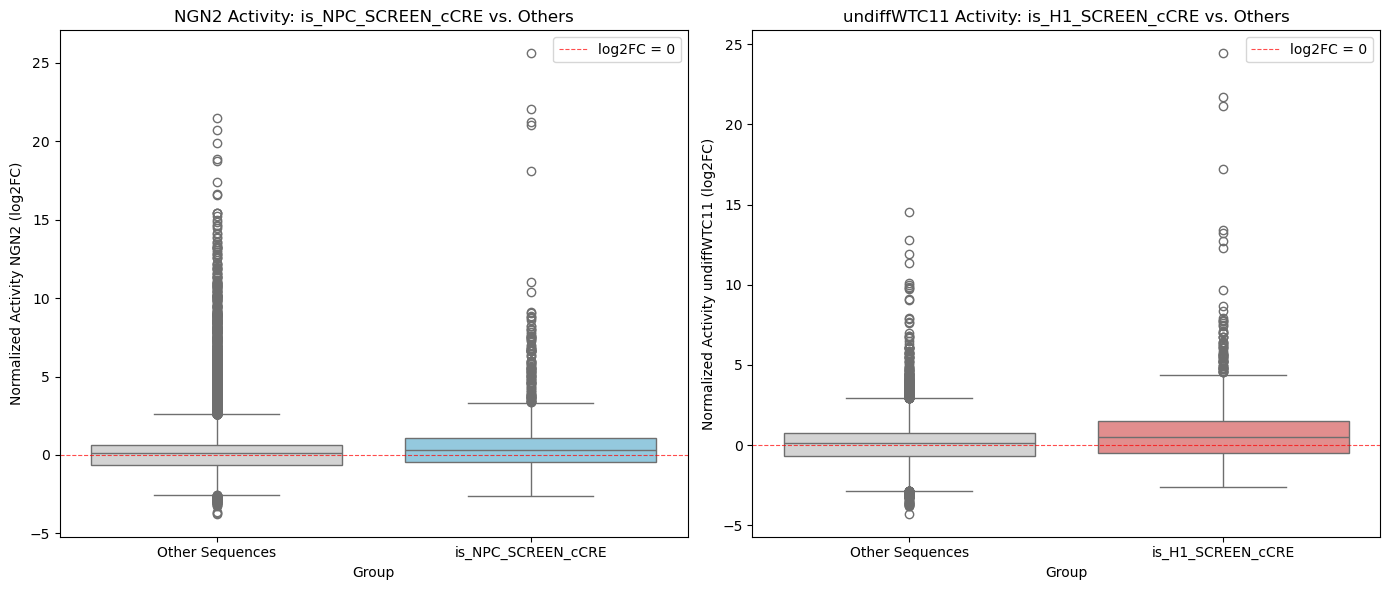

In [39]:
print("\n--- Question 3: Visualizing Activity Distributions ---")

plt.figure(figsize=(14, 6))

# Plot 1: NGN2 Activity
plt.subplot(1, 2, 1)
sns.boxplot(x=df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: 'is_NPC_SCREEN_cCRE', False: 'Other Sequences'}),
            y=df_elements_ngn2_focus['normalized_activity_NGN2'],
            palette={'is_NPC_SCREEN_cCRE': 'skyblue', 'Other Sequences': 'lightgray'})
plt.title('NGN2 Activity: is_NPC_SCREEN_cCRE vs. Others')
plt.xlabel('Group')
# plt.ylabel('Raw Activity NGN2 (log2FC)')
plt.ylabel('Normalized Activity NGN2 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0') # Add a line for no change
plt.legend()


# Plot 2: undiffWTC11 Activity
plt.subplot(1, 2, 2)
sns.boxplot(x=df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: 'is_H1_SCREEN_cCRE', False: 'Other Sequences'}),
            y=df_elements_wtc11_focus['normalized_activity_undiffWTC11'],
            palette={'is_H1_SCREEN_cCRE': 'lightcoral', 'Other Sequences': 'lightgray'})
plt.title('undiffWTC11 Activity: is_H1_SCREEN_cCRE vs. Others')
plt.xlabel('Group')
# plt.ylabel('Raw Activity undiffWTC11 (log2FC)')
plt.ylabel('Normalized Activity undiffWTC11 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
plt.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_525485/2727558405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: 'is_NPC_SCREEN_cCRE', False: 'Other Sequences'}),
/tmp/ipykernel_525485/2727558405.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: 'is_H1_SCREEN_cCRE', False: 'Other Sequences'}),


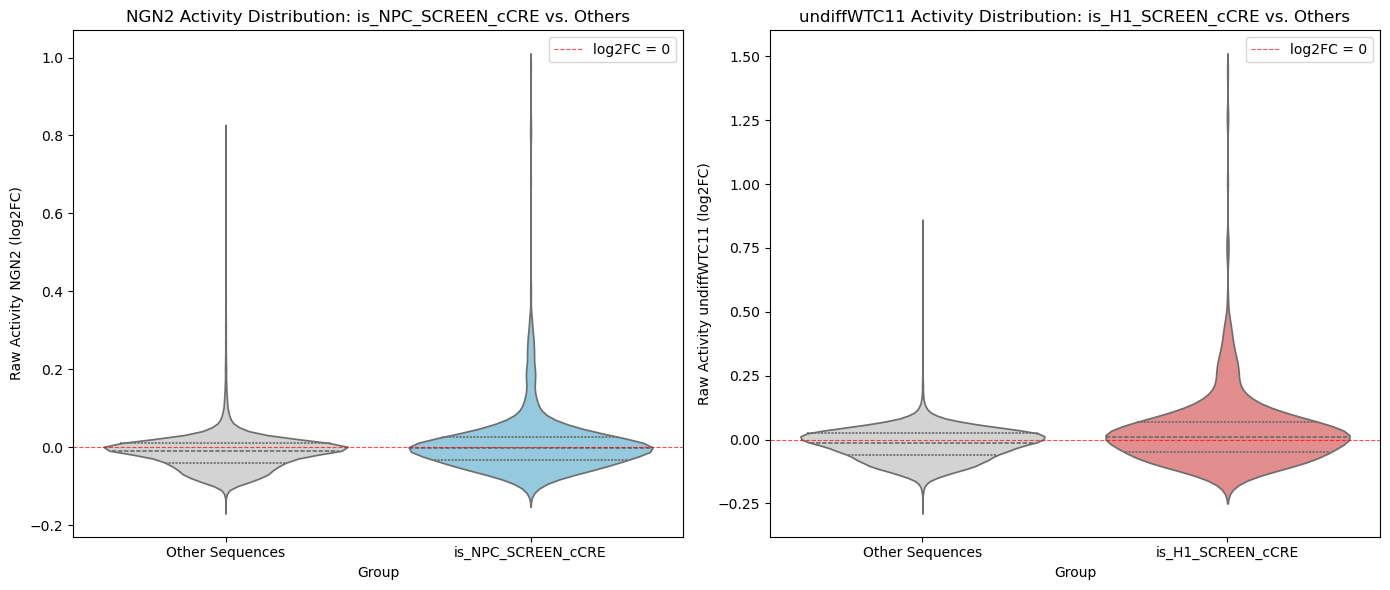

In [40]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x=df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: 'is_NPC_SCREEN_cCRE', False: 'Other Sequences'}),
               y=df_elements_ngn2_focus['raw_activity_NGN2_log2FC_bcalm'],
               palette={'is_NPC_SCREEN_cCRE': 'skyblue', 'Other Sequences': 'lightgray'},
               inner='quartile') # Shows quartiles
plt.title('NGN2 Activity Distribution: is_NPC_SCREEN_cCRE vs. Others')
plt.xlabel('Group')
plt.ylabel('Raw Activity NGN2 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
plt.legend()


plt.subplot(1, 2, 2)
sns.violinplot(x=df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: 'is_H1_SCREEN_cCRE', False: 'Other Sequences'}),
               y=df_elements_wtc11_focus['raw_activity_undiffWTC11_log2FC_bcalm'],
               palette={'is_H1_SCREEN_cCRE': 'lightcoral', 'Other Sequences': 'lightgray'},
               inner='quartile')
plt.title('undiffWTC11 Activity Distribution: is_H1_SCREEN_cCRE vs. Others')
plt.xlabel('Group')
plt.ylabel('Raw Activity undiffWTC11 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].value_counts()

is_NPC_SCREEN_cCRE
False    66504
True      1737
Name: count, dtype: int64

use the excitatory neuron results: 
- only 831 overlap NPC: 1737

/tmp/ipykernel_525485/1405049423.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NPC_Group',


Other Sequences
0
67410
is_excitatory_neuron_SCREEN_cCRE
1
831


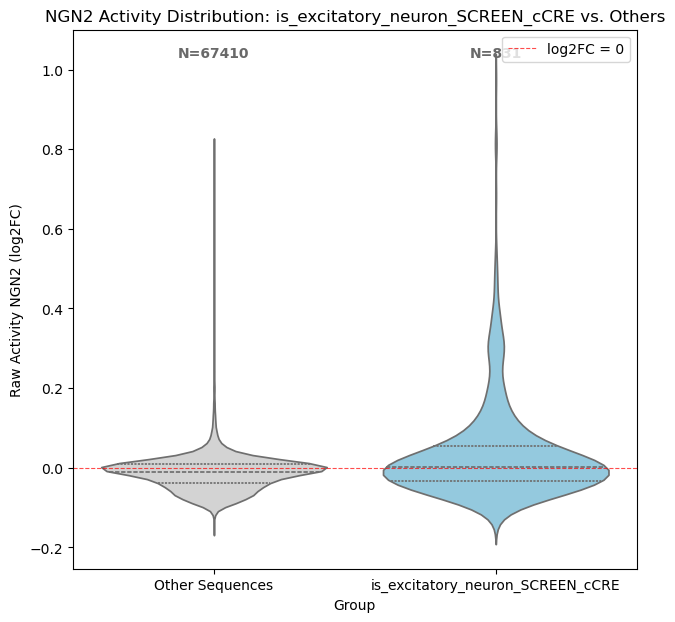

In [46]:
plt.figure(figsize=(16, 7)) # Increased figure size for better readability

# Plot 1: NGN2 Activity
plt.subplot(1, 2, 1)

# Map boolean to string labels for plotting
df_elements_ngn2_focus['NPC_Group'] = df_elements_ngn2_focus['is_excitatory_neuron_SCREEN_cCRE'].map({True: 'is_excitatory_neuron_SCREEN_cCRE', False: 'Other Sequences'})
sns.violinplot(x='NPC_Group',
               y='raw_activity_NGN2_log2FC_bcalm',
               data=df_elements_ngn2_focus,
               palette={'is_excitatory_neuron_SCREEN_cCRE': 'skyblue', 'Other Sequences': 'lightgray'},
               inner='quartile') # Shows quartiles
plt.title('NGN2 Activity Distribution: is_excitatory_neuron_SCREEN_cCRE vs. Others')
plt.xlabel('Group')
plt.ylabel('Raw Activity NGN2 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
plt.legend()

# Add group sizes as text annotations
group_sizes_ngn2 = df_elements_ngn2_focus['NPC_Group'].value_counts()
for i, group_name in enumerate(['Other Sequences', 'is_excitatory_neuron_SCREEN_cCRE']):
    print(group_name)
    print(i)
    size = group_sizes_ngn2.get(group_name, 0)
    print(size)
    # Adjust y-coordinate based on the data range to place text outside the violin
    # A common strategy is to place it slightly above the max value or within the top quarter
    y_text_pos = df_elements_ngn2_focus['raw_activity_NGN2_log2FC_bcalm'].max() * 1.05 # Adjust multiplier as needed
    if pd.isna(y_text_pos): # Handle cases where max might be NaN for empty groups or specific data ranges
        y_text_pos = 0 # Fallback to a reasonable default

    plt.text(i, y_text_pos, f'N={size}',
             ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

Use the combined results: 


/tmp/ipykernel_525485/2349296657.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NPC_Group',


Other Sequences
0
65818
is_npc_or_excitatory_SCREEN_cre
1
2423


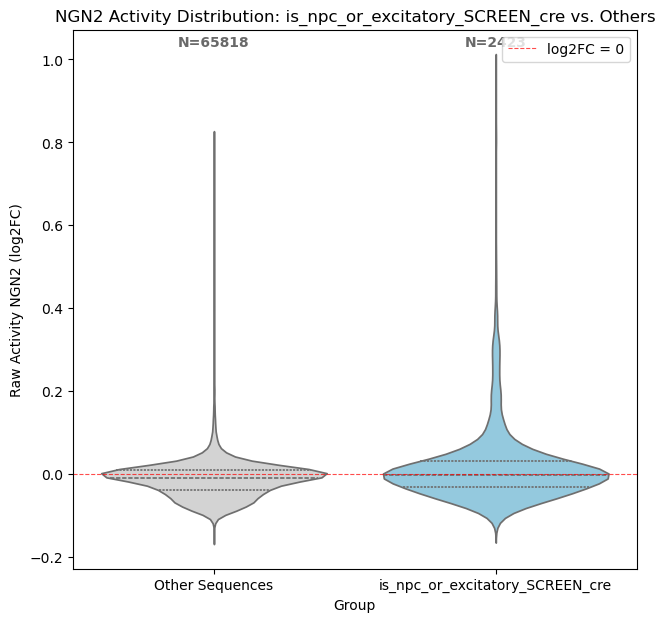

In [62]:
plt.figure(figsize=(16, 7)) # Increased figure size for better readability

# Plot 1: NGN2 Activity
plt.subplot(1, 2, 1)

# Map boolean to string labels for plotting
df_elements_ngn2_focus['NPC_Group'] = df_elements_ngn2_focus['is_npc_or_excitatory_SCREEN_cre'].map({True: 'is_npc_or_excitatory_SCREEN_cre', False: 'Other Sequences'})
sns.violinplot(x='NPC_Group',
               y='raw_activity_NGN2_log2FC_bcalm',
               data=df_elements_ngn2_focus,
               palette={'is_npc_or_excitatory_SCREEN_cre': 'skyblue', 'Other Sequences': 'lightgray'},
               inner='quartile') # Shows quartiles
plt.title('NGN2 Activity Distribution: is_npc_or_excitatory_SCREEN_cre vs. Others')
plt.xlabel('Group')
plt.ylabel('Raw Activity NGN2 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
plt.legend()

# Add group sizes as text annotations
group_sizes_ngn2 = df_elements_ngn2_focus['NPC_Group'].value_counts()
for i, group_name in enumerate(['Other Sequences', 'is_npc_or_excitatory_SCREEN_cre']):
    print(group_name)
    print(i)
    size = group_sizes_ngn2.get(group_name, 0)
    print(size)
    # Adjust y-coordinate based on the data range to place text outside the violin
    # A common strategy is to place it slightly above the max value or within the top quarter
    y_text_pos = df_elements_ngn2_focus['raw_activity_NGN2_log2FC_bcalm'].max() * 1.05 # Adjust multiplier as needed
    if pd.isna(y_text_pos): # Handle cases where max might be NaN for empty groups or specific data ranges
        y_text_pos = 0 # Fallback to a reasonable default

    plt.text(i, y_text_pos, f'N={size}',
             ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

/tmp/ipykernel_525485/3726802059.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NPC_Group',


Other Sequences
0
66504
is_NPC_SCREEN_cCRE
1
1737


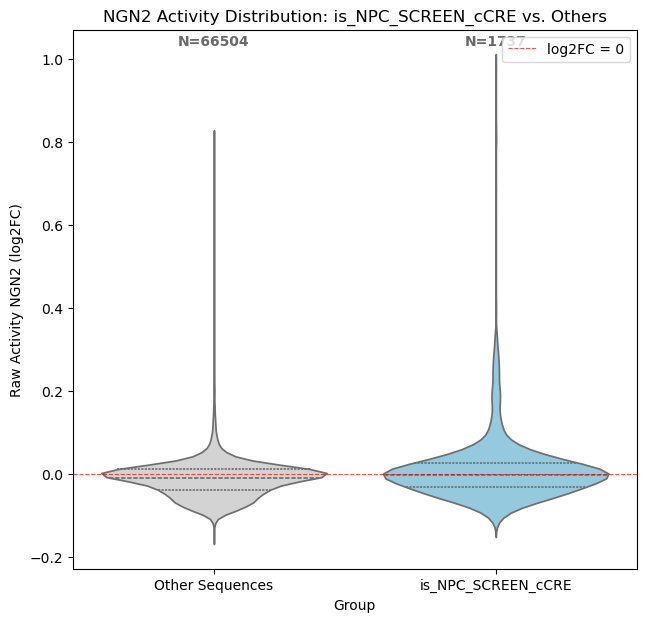

In [48]:
plt.figure(figsize=(16, 7)) # Increased figure size for better readability

# Plot 1: NGN2 Activity
plt.subplot(1, 2, 1)

# Map boolean to string labels for plotting
df_elements_ngn2_focus['NPC_Group'] = df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: 'is_NPC_SCREEN_cCRE', False: 'Other Sequences'})
sns.violinplot(x='NPC_Group',
               y='raw_activity_NGN2_log2FC_bcalm',
               data=df_elements_ngn2_focus,
               palette={'is_NPC_SCREEN_cCRE': 'skyblue', 'Other Sequences': 'lightgray'},
               inner='quartile') # Shows quartiles
plt.title('NGN2 Activity Distribution: is_NPC_SCREEN_cCRE vs. Others')
plt.xlabel('Group')
plt.ylabel('Raw Activity NGN2 (log2FC)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
plt.legend()

# Add group sizes as text annotations
group_sizes_ngn2 = df_elements_ngn2_focus['NPC_Group'].value_counts()
for i, group_name in enumerate(['Other Sequences', 'is_NPC_SCREEN_cCRE']):
    print(group_name)
    print(i)
    size = group_sizes_ngn2.get(group_name, 0)
    print(size)
    # Adjust y-coordinate based on the data range to place text outside the violin
    # A common strategy is to place it slightly above the max value or within the top quarter
    y_text_pos = df_elements_ngn2_focus['raw_activity_NGN2_log2FC_bcalm'].max() * 1.05 # Adjust multiplier as needed
    if pd.isna(y_text_pos): # Handle cases where max might be NaN for empty groups or specific data ranges
        y_text_pos = 0 # Fallback to a reasonable default

    plt.text(i, y_text_pos, f'N={size}',
             ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')


# # Plot 2: undiffWTC11 Activity
# plt.subplot(1, 2, 2)

# # Map boolean to string labels for plotting
# df_elements_wtc11_focus['H1_Group'] = df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: 'is_H1_SCREEN_cCRE', False: 'Other Sequences'})
# sns.violinplot(x='H1_Group',
#                y='raw_activity_undiffWTC11_log2FC_bcalm',
#                data=df_elements_wtc11_focus,
#                palette={'is_H1_SCREEN_cCRE': 'lightcoral', 'Other Sequences': 'lightgray'},
#                inner='quartile')
# plt.title('undiffWTC11 Activity Distribution: is_H1_SCREEN_cCRE vs. Others')
# plt.xlabel('Group')
# plt.ylabel('Raw Activity undiffWTC11 (log2FC)')
# plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
# plt.legend()

# # Add group sizes as text annotations
# group_sizes_wtc11 = df_elements_wtc11_focus['H1_Group'].value_counts()
# for i, group_name in enumerate(['is_H1_SCREEN_cCRE', 'Other Sequences']):
#     size = group_sizes_wtc11.get(group_name, 0)
#     y_text_pos = df_elements_wtc11_focus['raw_activity_undiffWTC11_log2FC_bcalm'].max() * 1.05 # Adjust multiplier as needed
#     if pd.isna(y_text_pos):
#         y_text_pos = 0 # Fallback

#     plt.text(i, y_text_pos, f'N={size}',
#              ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

# plt.tight_layout()
# plt.show()

# # Clean up temporary columns if no longer needed
# df_elements_ngn2_focus = df_elements_ngn2_focus.drop(columns=['NPC_Group'])
# df_elements_wtc11_focus = df_elements_wtc11_focus.drop(columns=['H1_Group'])


--- Question 3: Visualizing Activity Distributions with Group Sizes ---


/tmp/ipykernel_525485/3743696130.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NPC_Group_Plot',
/tmp/ipykernel_525485/3743696130.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='H1_Group_Plot',


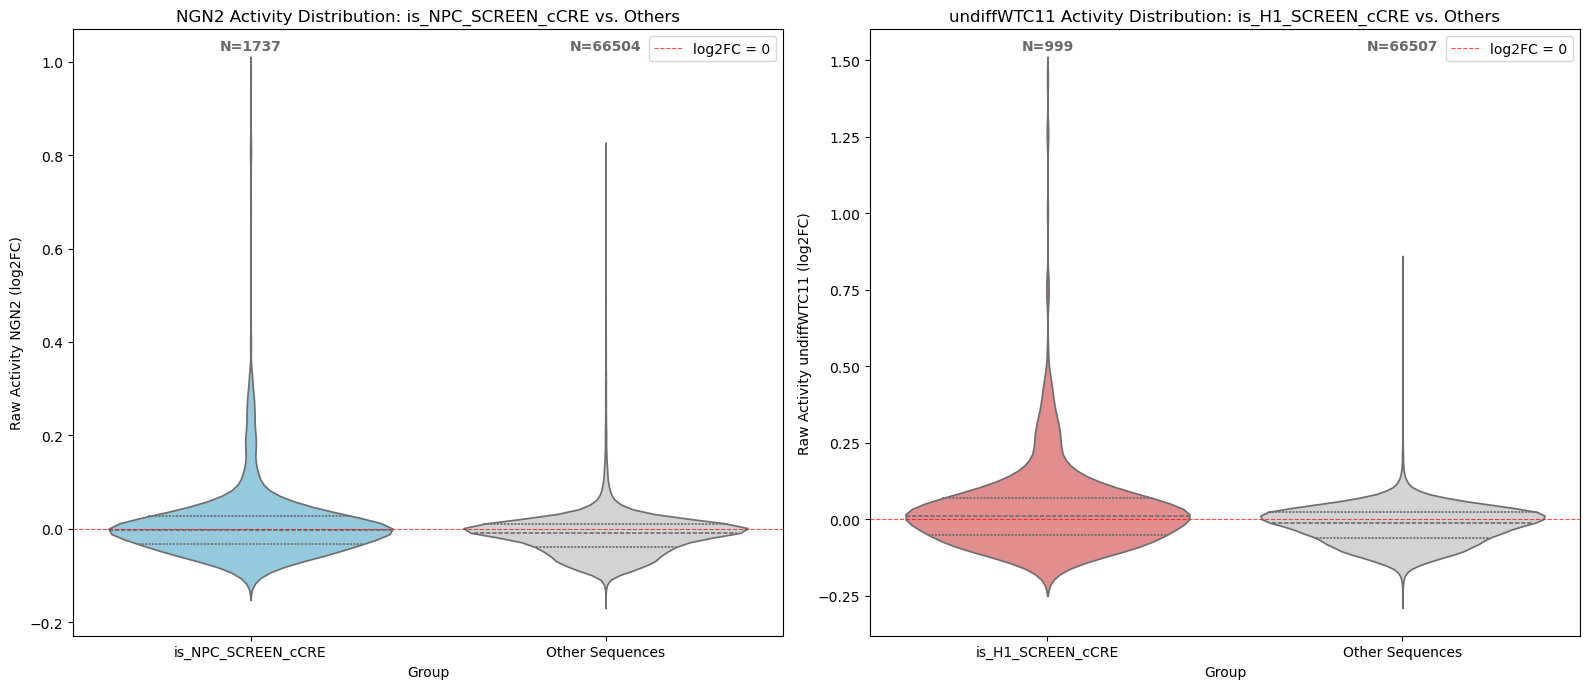

In [49]:
print("\n--- Question 3: Visualizing Activity Distributions with Group Sizes ---")

plt.figure(figsize=(16, 7)) # Increased figure size for better readability

# Plot 1: NGN2 Activity
ax1 = plt.subplot(1, 2, 1) # Get the axes object

# Map boolean to string labels for plotting
# Explicitly set order to ensure consistency
ngn2_group_labels = ['is_NPC_SCREEN_cCRE', 'Other Sequences']
df_elements_ngn2_focus['NPC_Group_Plot'] = df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: ngn2_group_labels[0], False: ngn2_group_labels[1]})

sns.violinplot(x='NPC_Group_Plot',
               y='raw_activity_NGN2_log2FC_bcalm',
               data=df_elements_ngn2_focus,
               order=ngn2_group_labels, # Explicitly set order
               palette={ngn2_group_labels[0]: 'skyblue', ngn2_group_labels[1]: 'lightgray'},
               inner='quartile',
               ax=ax1) # Pass the axes object

ax1.set_title('NGN2 Activity Distribution: is_NPC_SCREEN_cCRE vs. Others')
ax1.set_xlabel('Group')
ax1.set_ylabel('Raw Activity NGN2 (log2FC)')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
ax1.legend()


# Add group sizes as text annotations
group_sizes_ngn2 = df_elements_ngn2_focus['NPC_Group_Plot'].value_counts()
for i, group_label in enumerate(ngn2_group_labels): # Iterate through the explicit order
    size = group_sizes_ngn2.get(group_label, 0)
    # Determine y-position based on plot limits, adding a small margin
    y_min, y_max = ax1.get_ylim()
    y_text_pos = y_max * 0.98

    # Adjusted x-coordinate for text placement using axis.get_xticks()
    x_coords = ax1.get_xticks() # Get the x-tick locations

    # If the group has no data, skip annotation or handle as needed
    if size > 0:
        ax1.text(x_coords[i], y_text_pos, f'N={size}',
                 ha='center', va='top', fontsize=10, color='dimgray', weight='bold')


# Plot 2: undiffWTC11 Activity
ax2 = plt.subplot(1, 2, 2) # Get the axes object

# Map boolean to string labels for plotting
h1_group_labels = ['is_H1_SCREEN_cCRE', 'Other Sequences']
df_elements_wtc11_focus['H1_Group_Plot'] = df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: h1_group_labels[0], False: h1_group_labels[1]})

sns.violinplot(x='H1_Group_Plot',
               y='raw_activity_undiffWTC11_log2FC_bcalm',
               data=df_elements_wtc11_focus,
               order=h1_group_labels, # Explicitly set order
               palette={h1_group_labels[0]: 'lightcoral', h1_group_labels[1]: 'lightgray'},
               inner='quartile',
               ax=ax2) # Pass the axes object

ax2.set_title('undiffWTC11 Activity Distribution: is_H1_SCREEN_cCRE vs. Others')
ax2.set_xlabel('Group')
ax2.set_ylabel('Raw Activity undiffWTC11 (log2FC)')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')
ax2.legend()

# Add group sizes as text annotations
group_sizes_wtc11 = df_elements_wtc11_focus['H1_Group_Plot'].value_counts()
for i, group_label in enumerate(h1_group_labels): # Iterate through the explicit order
    size = group_sizes_wtc11.get(group_label, 0)
    y_min, y_max = ax2.get_ylim()
    y_text_pos = y_max * 0.98 # Place text near the top, within the plot area

    x_coords = ax2.get_xticks() # Get the x-tick locations

    if size > 0:
        ax2.text(x_coords[i], y_text_pos, f'N={size}',
                 ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

plt.tight_layout()
plt.show()


In [50]:
df_elements_ngn2_focus.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'NPC_Group', 'NPC_Group_Plot'],
      dtype='object')


--- Question 3: Visualizing Activity Distributions with Consistent Y-Limits and External Legends ---


/tmp/ipykernel_525485/1962135339.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NPC_Group_Plot',
/tmp/ipykernel_525485/1962135339.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='H1_Group_Plot',


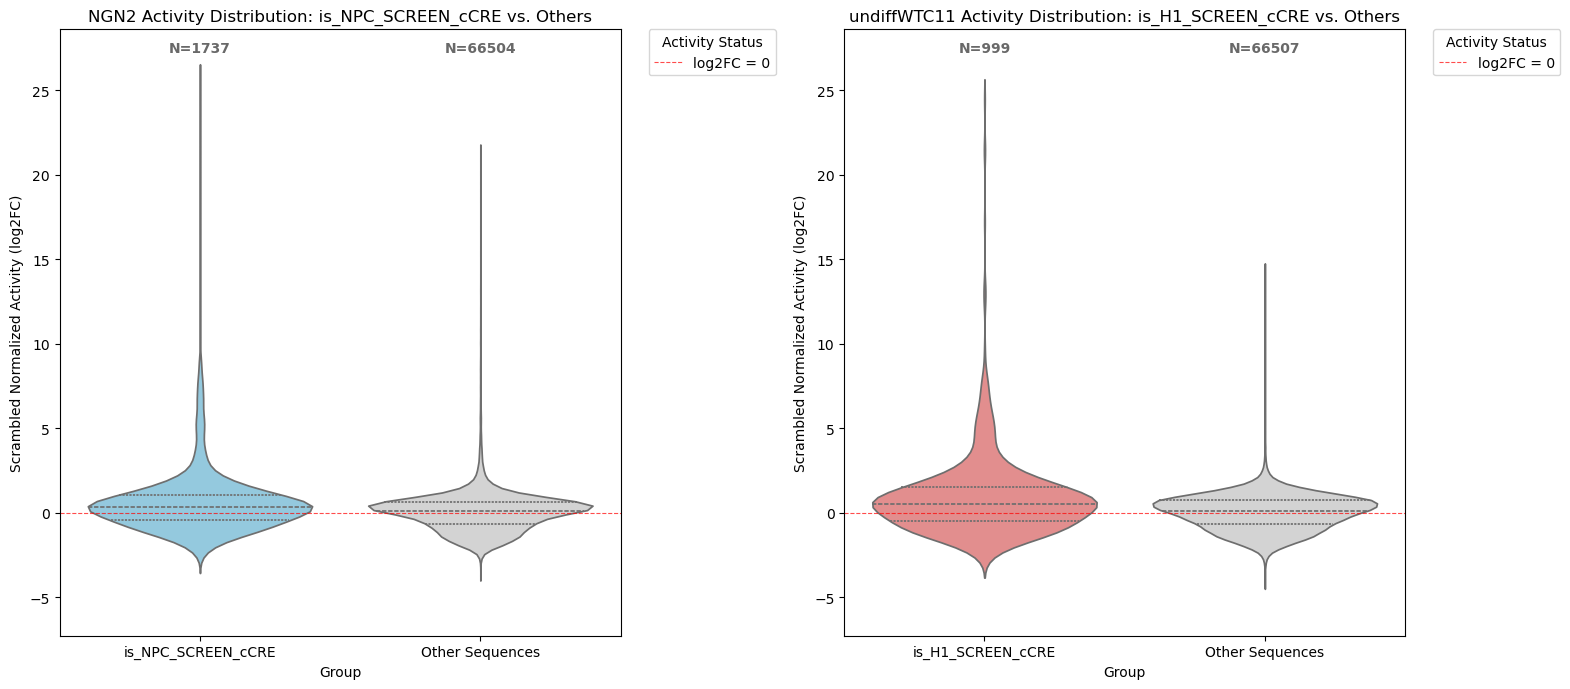

In [51]:
print("\n--- Question 3: Visualizing Activity Distributions with Consistent Y-Limits and External Legends ---")

plt.figure(figsize=(18, 7)) # Increased figure width for external legends

# Calculate global min and max for raw activity across both relevant columns and dataframes
global_min_activity = min(df_elements_ngn2_focus['normalized_activity_NGN2'].min(),
                          df_elements_wtc11_focus['normalized_activity_undiffWTC11'].min())
global_max_activity = max(df_elements_ngn2_focus['normalized_activity_NGN2'].max(),
                          df_elements_wtc11_focus['normalized_activity_undiffWTC11'].max())

# Add a small buffer to the limits for better visualization
y_lim_buffer = (global_max_activity - global_min_activity) * 0.1
consistent_ylim_min = global_min_activity - y_lim_buffer
consistent_ylim_max = global_max_activity + y_lim_buffer


# Plot 1: NGN2 Activity
ax1 = plt.subplot(1, 2, 1) # Get the axes object

# Map boolean to string labels for plotting
ngn2_group_labels = ['is_NPC_SCREEN_cCRE', 'Other Sequences']
df_elements_ngn2_focus['NPC_Group_Plot'] = df_elements_ngn2_focus['is_NPC_SCREEN_cCRE'].map({True: ngn2_group_labels[0], False: ngn2_group_labels[1]})

sns.violinplot(x='NPC_Group_Plot',
               y='normalized_activity_NGN2',
               data=df_elements_ngn2_focus,
               order=ngn2_group_labels, # Explicitly set order
               palette={ngn2_group_labels[0]: 'skyblue', ngn2_group_labels[1]: 'lightgray'},
               inner='quartile',
               ax=ax1) # Pass the axes object

ax1.set_title('NGN2 Activity Distribution: is_NPC_SCREEN_cCRE vs. Others')
ax1.set_xlabel('Group')
ax1.set_ylabel('Scrambled Normalized Activity (log2FC)')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')

# Set consistent y-limits
ax1.set_ylim(consistent_ylim_min, consistent_ylim_max)

# Move legend outside for ax1
ax1.legend(title='Activity Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# Add group sizes as text annotations
group_sizes_ngn2 = df_elements_ngn2_focus['NPC_Group_Plot'].value_counts()
for i, group_label in enumerate(ngn2_group_labels): # Iterate through the explicit order
    size = group_sizes_ngn2.get(group_label, 0)
    # Determine y-position based on plot limits, placing it consistently above the max range
    y_text_pos = consistent_ylim_max - (consistent_ylim_max - consistent_ylim_min) * 0.02 # A small buffer from top

    # Adjusted x-coordinate for text placement using axis.get_xticks()
    x_coords = ax1.get_xticks() # Get the x-tick locations

    # If the group has no data, skip annotation or handle as needed
    if size > 0:
        ax1.text(x_coords[i], y_text_pos, f'N={size}',
                 ha='center', va='top', fontsize=10, color='dimgray', weight='bold')


# Plot 2: undiffWTC11 Activity
ax2 = plt.subplot(1, 2, 2) # Get the axes object

# Map boolean to string labels for plotting
h1_group_labels = ['is_H1_SCREEN_cCRE', 'Other Sequences']
df_elements_wtc11_focus['H1_Group_Plot'] = df_elements_wtc11_focus['is_H1_SCREEN_cCRE'].map({True: h1_group_labels[0], False: h1_group_labels[1]})

sns.violinplot(x='H1_Group_Plot',
               y='normalized_activity_undiffWTC11',
               data=df_elements_wtc11_focus,
               order=h1_group_labels, # Explicitly set order
               palette={h1_group_labels[0]: 'lightcoral', h1_group_labels[1]: 'lightgray'},
               inner='quartile',
               ax=ax2) # Pass the axes object

ax2.set_title('undiffWTC11 Activity Distribution: is_H1_SCREEN_cCRE vs. Others')
ax2.set_xlabel('Group')
ax2.set_ylabel('Scrambled Normalized Activity (log2FC)')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='log2FC = 0')

# Set consistent y-limits
ax2.set_ylim(consistent_ylim_min, consistent_ylim_max)

# Move legend outside for ax2
ax2.legend(title='Activity Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Add group sizes as text annotations
group_sizes_wtc11 = df_elements_wtc11_focus['H1_Group_Plot'].value_counts()
for i, group_label in enumerate(h1_group_labels): # Iterate through the explicit order
    size = group_sizes_wtc11.get(group_label, 0)
    y_text_pos = consistent_ylim_max - (consistent_ylim_max - consistent_ylim_min) * 0.02 # Consistent y-position

    x_coords = ax2.get_xticks() # Get the x-tick locations

    if size > 0:
        ax2.text(x_coords[i], y_text_pos, f'N={size}',
                 ha='center', va='top', fontsize=10, color='dimgray', weight='bold')

plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjust layout to make space for legends on the right
plt.show()

# Clean up temporary columns if no longer needed
# Make sure to drop these only if they were added in this specific script run.
# If they are already part of your DFs, skip this.
if 'NPC_Group_Plot' in df_elements_ngn2_focus.columns:
    df_elements_ngn2_focus = df_elements_ngn2_focus.drop(columns=['NPC_Group_Plot'])
if 'H1_Group_Plot' in df_elements_wtc11_focus.columns:
    df_elements_wtc11_focus = df_elements_wtc11_focus.drop(columns=['H1_Group_Plot'])


In [52]:
df_elements_wtc11_focus.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes'],
      dtype='object')

In [53]:
df_elements_wtc11_focus['bcalm_effect_undiffWTC11'].value_counts()

bcalm_effect_undiffWTC11
no_effect     67080
increasing      393
decreasing       33
Name: count, dtype: int64

#### 4. Is the number of "is_dCRE_WTC11" enriched in the group defined by "is_H1_SCREEN_cCRE" compared to the other sequences?

In [54]:
# --- Function to perform Fisher's Exact Test ---
def perform_fisher_enrichment(df, group_col, target_col, group_name):
    """
    Performs Fisher's exact test for enrichment of a target_col (boolean)
    within a specific group_col (boolean) compared to the rest of the data.

    Args:
        df (pd.DataFrame): The input DataFrame.
        group_col (str): The name of the boolean column defining the group (e.g., 'is_NPC_SCREEN_cCRE').
        target_col (str): The name of the boolean column to test for enrichment (e.g., 'is_dCRE_NGN2').
        group_name (str): A descriptive name for the group (e.g., 'NPC SCREEN cCREs').

    Returns:
        tuple: A tuple containing (odds_ratio, p_value, contingency_table).
               Returns (None, None, None) if groups are too small.
    """
    # Contingency table:
    #                 Target_True   Target_False
    # Group_True      a             b
    # Group_False     c             d

    a = df[(df[group_col] == True) & (df[target_col] == True)].shape[0]
    b = df[(df[group_col] == True) & (df[target_col] == False)].shape[0]
    c = df[(df[group_col] == False) & (df[target_col] == True)].shape[0]
    d = df[(df[group_col] == False) & (df[target_col] == False)].shape[0]

    contingency_table = pd.DataFrame([
        [a, b],
        [c, d]
    ], index=[group_name, f'Not {group_name}'], columns=[f'{target_col} True', f'{target_col} False'])

    print(f"\nContingency Table for {group_col} vs. {target_col}:")
    print(contingency_table)

    # Fisher's exact test requires no zeros in the table for proper calculation
    # though scipy's implementation can often handle it.
    # It's good practice to check if total counts are meaningful.
    if contingency_table.sum().sum() == 0 or a + b == 0 or c + d == 0:
        print("Warning: Insufficient data to perform Fisher's exact test.")
        return None, None, contingency_table


    # We use 'greater' to test for enrichment (odds ratio > 1)
    odds_ratio, p_value = stats.fisher_exact(contingency_table.values, alternative='greater')

    print(f"Fisher's Exact Test Results:")
    print(f"  Odds Ratio: {odds_ratio:.2f}")
    print(f"  P-value: {p_value:.3e}")

    if p_value < 0.05:
        print(f"  Conclusion: '{target_col}' is significantly enriched in '{group_name}' (p < 0.05, Odds Ratio > 1).")
    else:
        print(f"  Conclusion: No significant enrichment of '{target_col}' detected in '{group_name}' (p >= 0.05).")

    return odds_ratio, p_value, contingency_table


# 4. Is the number of "is_dCRE_WTC11" enriched in the group defined by "is_H1_SCREEN_cCRE" compared to the other sequences?
print("\n--- Question 4: Enrichment of is_dCRE_undiffWTC11 in is_H1_SCREEN_cCRE ---")
odds_ratio_q4, p_value_q4, _ = perform_fisher_enrichment(
    df_elements_wtc11_focus,
    group_col='is_H1_SCREEN_cCRE',
    target_col='is_dCRE_undiffWTC11',
    group_name='H1 SCREEN cCREs'
)


--- Question 4: Enrichment of is_dCRE_undiffWTC11 in is_H1_SCREEN_cCRE ---

Contingency Table for is_H1_SCREEN_cCRE vs. is_dCRE_undiffWTC11:
                     is_dCRE_undiffWTC11 True  is_dCRE_undiffWTC11 False
H1 SCREEN cCREs                           109                        890
Not H1 SCREEN cCREs                       317                      66190
Fisher's Exact Test Results:
  Odds Ratio: 25.57
  P-value: 9.491e-101
  Conclusion: 'is_dCRE_undiffWTC11' is significantly enriched in 'H1 SCREEN cCREs' (p < 0.05, Odds Ratio > 1).


In [55]:
# 5. Is the number of "is_dCRE_NGN2" enriched in the group defined by "is_NPC_SCREEN_cCRE" compared to the other sequences?
print("\n--- Question 5: Enrichment of is_dCRE_NGN2 in is_NPC_SCREEN_cCRE ---")
odds_ratio_q5, p_value_q5, _ = perform_fisher_enrichment(
    df_elements_ngn2_focus,
    group_col='is_NPC_SCREEN_cCRE',
    target_col='is_dCRE_NGN2',
    group_name='NPC SCREEN cCREs'
)


--- Question 5: Enrichment of is_dCRE_NGN2 in is_NPC_SCREEN_cCRE ---

Contingency Table for is_NPC_SCREEN_cCRE vs. is_dCRE_NGN2:
                      is_dCRE_NGN2 True  is_dCRE_NGN2 False
NPC SCREEN cCREs                    204                1533
Not NPC SCREEN cCREs               3557               62947
Fisher's Exact Test Results:
  Odds Ratio: 2.35
  P-value: 2.428e-24
  Conclusion: 'is_dCRE_NGN2' is significantly enriched in 'NPC SCREEN cCREs' (p < 0.05, Odds Ratio > 1).


In [63]:
# 5. Is the number of "is_dCRE_NGN2" enriched in the group defined by "is_excitatory_neuron_SCREEN_cCRE" compared to the other sequences?
print("\n--- Question 5: Enrichment of is_dCRE_NGN2 in is_excitatory_neuron_SCREEN_cCRE ---")
odds_ratio_q5, p_value_q5, _ = perform_fisher_enrichment(
    df_elements_ngn2_focus,
    group_col='is_excitatory_neuron_SCREEN_cCRE',
    target_col='is_dCRE_NGN2',
    group_name='excitatory SCREEN cCREs'
)


--- Question 5: Enrichment of is_dCRE_NGN2 in is_excitatory_neuron_SCREEN_cCRE ---

Contingency Table for is_excitatory_neuron_SCREEN_cCRE vs. is_dCRE_NGN2:
                             is_dCRE_NGN2 True  is_dCRE_NGN2 False
excitatory SCREEN cCREs                    177                 654
Not excitatory SCREEN cCREs               3584               63826
Fisher's Exact Test Results:
  Odds Ratio: 4.82
  P-value: 3.735e-55
  Conclusion: 'is_dCRE_NGN2' is significantly enriched in 'excitatory SCREEN cCREs' (p < 0.05, Odds Ratio > 1).


In [64]:
df_elements_ngn2_focus.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_SCREEN_cre',
       'NPC_Group'],
      dtype='object')

In [65]:
# 5. Is the number of "is_dCRE_NGN2" enriched in the group defined by "is_npc_or_excitatory_SCREEN_cre" compared to the other sequences?
print("\n--- Question 5: Enrichment of is_dCRE_NGN2 in is_npc_or_excitatory_SCREEN_cre ---")
odds_ratio_q5, p_value_q5, _ = perform_fisher_enrichment(
    df_elements_ngn2_focus,
    group_col='is_npc_or_excitatory_SCREEN_cre',
    target_col='is_dCRE_NGN2',
    group_name='excitatory SCREEN cCREs'
)


--- Question 5: Enrichment of is_dCRE_NGN2 in is_npc_or_excitatory_SCREEN_cre ---

Contingency Table for is_npc_or_excitatory_SCREEN_cre vs. is_dCRE_NGN2:
                             is_dCRE_NGN2 True  is_dCRE_NGN2 False
excitatory SCREEN cCREs                    348                2075
Not excitatory SCREEN cCREs               3413               62405
Fisher's Exact Test Results:
  Odds Ratio: 3.07
  P-value: 2.895e-61
  Conclusion: 'is_dCRE_NGN2' is significantly enriched in 'excitatory SCREEN cCREs' (p < 0.05, Odds Ratio > 1).


In [67]:
df_elements_ngn2_focus.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_SCREEN_cre',
       'NPC_Group'],
      dtype='object')

#### Visualization
- proportion of dCREs vs not dCREs in undiffWTC11 data:


--- Visualizing Enrichment Results with Focus DataFrames and Consistent Palette ---


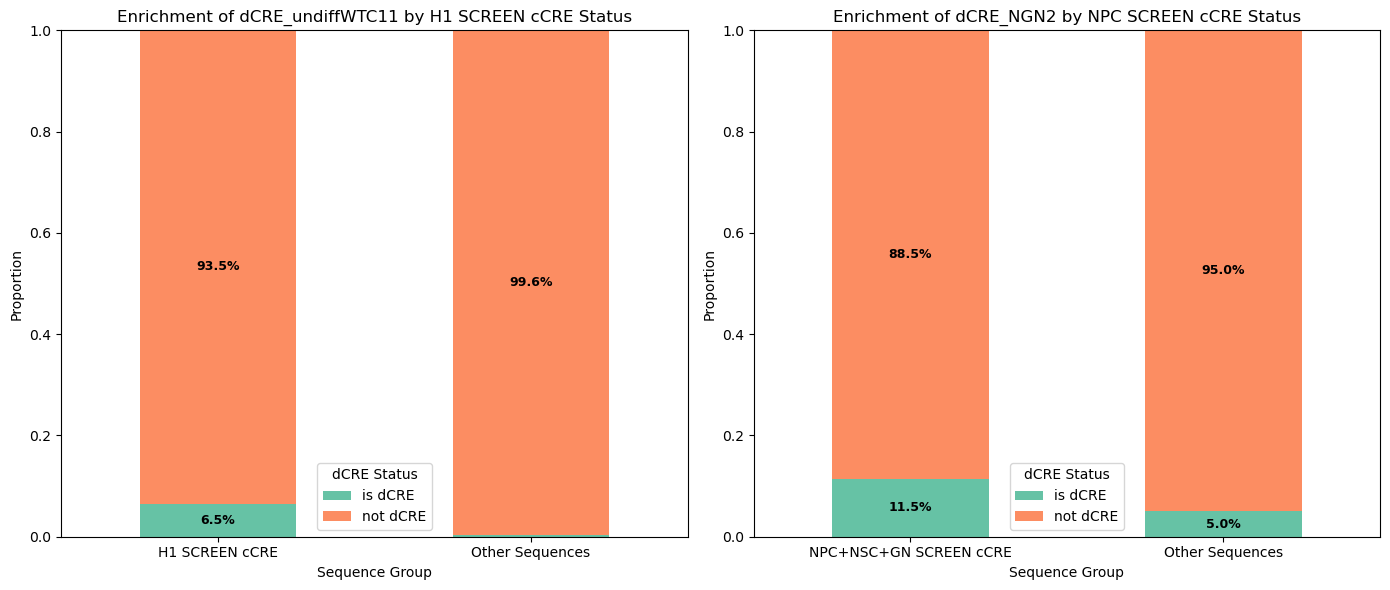

In [34]:
# --- Visualization for Enrichment Analyses (Questions 4 & 5) ---
print("\n--- Visualizing Enrichment Results with Focus DataFrames and Consistent Palette ---")

plt.figure(figsize=(14, 6))

# Define a consistent color palette for 'is dCRE' vs 'not dCRE'
# Using specific colors from Seaborn's 'Set2' palette as per your example's intention.
# sns.color_palette("Set2")[0] is a distinct color for the "enriched" category.
# sns.color_palette("Set2")[1] is a neutral color for "not dCRE".
dcre_colors = {
    'is dCRE': sns.color_palette("Set2")[0],
    'not dCRE': sns.color_palette("Set2")[1]
}

# Define the order of columns for stacking for consistency: 'is dCRE' at the bottom
stack_order = ['is dCRE', 'not dCRE']


# --- Plot 1: Enrichment of is_dCRE_undiffWTC11 in is_H1_SCREEN_cCRE ---
ax1_enrich = plt.subplot(1, 2, 1)

plot_df_enrich1 = df_elements_wtc11_focus.copy()
plot_df_enrich1['H1_SCREEN_Group'] = plot_df_enrich1['is_H1_SCREEN_cCRE'].map({True: 'H1 SCREEN cCRE', False: 'Other Sequences'})
plot_df_enrich1['dCRE_undiffWTC11_Status'] = plot_df_enrich1['is_dCRE_undiffWTC11'].map({True: 'is dCRE', False: 'not dCRE'})

proportions_enrich1 = plot_df_enrich1.groupby('H1_SCREEN_Group')['dCRE_undiffWTC11_Status'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols1 = proportions_enrich1.columns.tolist()
if 'is dCRE' not in current_cols1:
    proportions_enrich1['is dCRE'] = 0.0
if 'not dCRE' not in current_cols1:
    proportions_enrich1['not dCRE'] = 0.0
proportions_enrich1 = proportions_enrich1[stack_order]


# Pass the color dictionary to the 'color' argument, referencing the 'stack_order'
proportions_enrich1.plot(kind='bar', stacked=True, ax=ax1_enrich, color=[dcre_colors[col] for col in stack_order])
ax1_enrich.set_title('Enrichment of dCRE_undiffWTC11 by H1 SCREEN cCRE Status')
ax1_enrich.set_xlabel('Sequence Group')
ax1_enrich.set_ylabel('Proportion')
ax1_enrich.set_ylim(0, 1.0)
ax1_enrich.tick_params(axis='x', rotation=0)
ax1_enrich.legend(title='dCRE Status')

for container in ax1_enrich.containers:
    for patch in container.patches:
        height = patch.get_height()
        width = patch.get_width()
        x_val = patch.get_x()
        y_val = patch.get_y()
        if height > 0.01: # Only annotate if slice is large enough
            ax1_enrich.text(x_val + width / 2, y_val + height / 2,
                     f'{height:.1%}', ha='center', va='center', color='black', fontsize=9,
                     fontweight='bold')


# --- Plot 2: Enrichment of is_dCRE_NGN2 in is_NPC_SCREEN_cCRE ---
ax2_enrich = plt.subplot(1, 2, 2)

plot_df_enrich2 = df_elements_ngn2_focus.copy()
plot_df_enrich2['NPC_SCREEN_Group'] = plot_df_enrich2['is_NPC_SCREEN_cCRE'].map({True: 'NPC SCREEN cCRE', False: 'Other Sequences'})
plot_df_enrich2['NPC_SCREEN_Group'] = plot_df_enrich2['is_npc_or_excitatory_SCREEN_cre'].map({True: 'neural cell SCREEN cCRE', False: 'Other Sequences'})
plot_df_enrich2['NPC_NSC_GN_SCREEN_Group'] = plot_df_enrich2['is_npc_or_excitatory_NSC_SCREEN_cre'].map({True: 'NPC+NSC+GN SCREEN cCRE', False: 'Other Sequences'})
plot_df_enrich2['dCRE_NGN2_Status'] = plot_df_enrich2['is_dCRE_NGN2'].map({True: 'is dCRE', False: 'not dCRE'})

proportions_enrich2 = plot_df_enrich2.groupby('NPC_NSC_GN_SCREEN_Group')['dCRE_NGN2_Status'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols2 = proportions_enrich2.columns.tolist()
if 'is dCRE' not in current_cols2:
    proportions_enrich2['is dCRE'] = 0.0
if 'not dCRE' not in current_cols2:
    proportions_enrich2['not dCRE'] = 0.0
proportions_enrich2 = proportions_enrich2[stack_order]


proportions_enrich2.plot(kind='bar', stacked=True, ax=ax2_enrich, color=[dcre_colors[col] for col in stack_order])
ax2_enrich.set_title('Enrichment of dCRE_NGN2 by NPC SCREEN cCRE Status')
ax2_enrich.set_xlabel('Sequence Group')
ax2_enrich.set_ylabel('Proportion')
ax2_enrich.set_ylim(0, 1.0)
ax2_enrich.tick_params(axis='x', rotation=0)
ax2_enrich.legend(title='dCRE Status')

for container in ax2_enrich.containers:
    for patch in container.patches:
        height = patch.get_height()
        width = patch.get_width()
        x_val = patch.get_x()
        y_val = patch.get_y()
        if height > 0.01:
            ax2_enrich.text(x_val + width / 2, y_val + height / 2,
                     f'{height:.1%}', ha='center', va='center', color='black', fontsize=9,
                     fontweight='bold')

plt.tight_layout()
plt.show()


--- Visualizing Enrichment Results with dCREs Split by Increasing/Decreasing ---


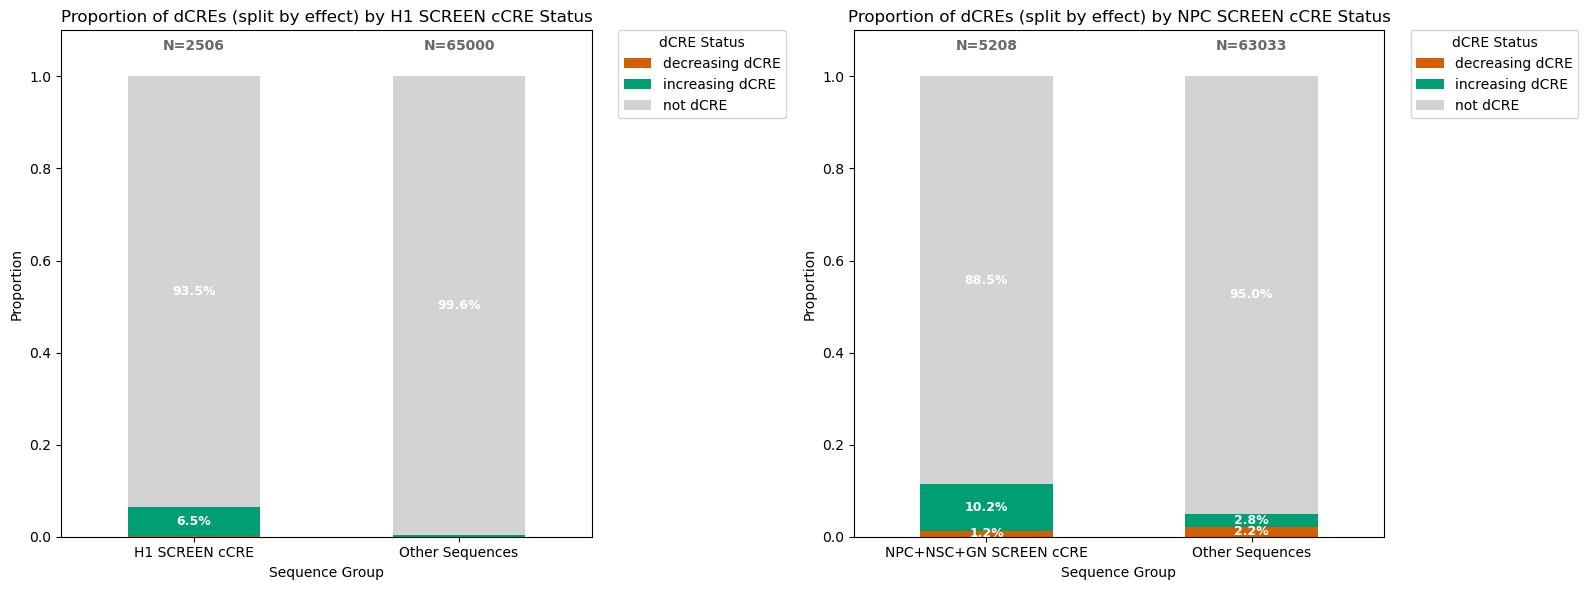

In [35]:
# --- Visualization for Enrichment Analyses with dCRE Split ---
print("\n--- Visualizing Enrichment Results with dCREs Split by Increasing/Decreasing ---")

plt.figure(figsize=(16, 6)) # Increased width for external legend

# Define colorblind-safe colors for 'increasing', 'decreasing', and 'not dCRE'
dcre_split_colors = {
    'decreasing dCRE': '#D55E00',  # Blue for decreasing dCRE
    'increasing dCRE': '#009E73', # Orange for increasing dCRE
    'not dCRE': 'lightgray'        # Neutral for non-dCREs
}

# Define the order of columns for stacking: decreasing dCRE at bottom, then increasing, then not dCRE
split_stack_order = ['decreasing dCRE', 'increasing dCRE', 'not dCRE']


# --- Plot 1: Enrichment of dCRE_undiffWTC11 split by effect in is_H1_SCREEN_cCRE ---
ax1_enrich = plt.subplot(1, 2, 1)

plot_df_enrich1 = df_elements_wtc11_focus.copy()
plot_df_enrich1['H1_SCREEN_Group'] = plot_df_enrich1['is_H1_SCREEN_cCRE'].map({True: 'H1 SCREEN cCRE', False: 'Other Sequences'})

# Create the new 'dCRE_Effect_Status' column based on is_dCRE AND effect type
def assign_dcre_status_wtc11(row):
    if row['is_dCRE_undiffWTC11'] and row['bcalm_effect_undiffWTC11'] == 'decreasing':
        return 'decreasing dCRE'
    elif row['is_dCRE_undiffWTC11'] and row['bcalm_effect_undiffWTC11'] == 'increasing':
        return 'increasing dCRE'
    else: # This handles 'not dCRE' and dCREs with 'no_effect' (if any, typically excluded from dCRE definition)
        return 'not dCRE'

plot_df_enrich1['dCRE_Effect_Status'] = plot_df_enrich1.apply(assign_dcre_status_wtc11, axis=1)

proportions_enrich1 = plot_df_enrich1.groupby('H1_SCREEN_Group')['dCRE_Effect_Status'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols1 = proportions_enrich1.columns.tolist()
for col in split_stack_order:
    if col not in current_cols1:
        proportions_enrich1[col] = 0.0
proportions_enrich1 = proportions_enrich1[split_stack_order]


# Pass the color dictionary to the 'color' argument, referencing the 'split_stack_order'
proportions_enrich1.plot(kind='bar', stacked=True, ax=ax1_enrich, color=[dcre_split_colors[col] for col in split_stack_order])
ax1_enrich.set_title('Proportion of dCREs (split by effect) by H1 SCREEN cCRE Status')
ax1_enrich.set_xlabel('Sequence Group')
ax1_enrich.set_ylabel('Proportion')
ax1_enrich.set_ylim(0, 1.1) # Adjusted y-limit for N= annotation
ax1_enrich.tick_params(axis='x', rotation=0)
ax1_enrich.legend(title='dCRE Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Annotate with total N for each group
for i, group_label in enumerate(proportions_enrich1.index):
    total_elements_in_group = plot_df_enrich1[plot_df_enrich1['H1_SCREEN_Group'] == group_label].shape[0]
    x_pos = i
    y_pos = 1.05
    ax1_enrich.text(x_pos, y_pos, f'N={total_elements_in_group}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

# Add percentages within the bars
for container in ax1_enrich.containers:
    for patch in container.patches:
        height = patch.get_height()
        width = patch.get_width()
        x_val = patch.get_x()
        y_val = patch.get_y()
        if height > 0.01: # Only annotate if slice is large enough
            # Use black text for light colors, white for dark colors
            text_color = 'black' if patch.get_facecolor() in ['#A9CDD9', '#E76CAD', 'lightgray'] else 'white'
            ax1_enrich.text(x_val + width / 2, y_val + height / 2,
                             f'{height:.1%}', ha='center', va='center', color=text_color, fontsize=9,
                             fontweight='bold')


# --- Plot 2: Enrichment of dCRE_NGN2 split by effect in is_NPC_SCREEN_cCRE ---
ax2_enrich = plt.subplot(1, 2, 2)

plot_df_enrich2 = df_elements_ngn2_focus.copy()
plot_df_enrich2['NPC_SCREEN_Group'] = plot_df_enrich2['is_NPC_SCREEN_cCRE'].map({True: 'NPC SCREEN cCRE', False: 'Other Sequences'})
plot_df_enrich2['NPC_NSC_GN_SCREEN_Group'] = plot_df_enrich2['is_npc_or_excitatory_NSC_SCREEN_cre'].map({True: 'NPC+NSC+GN SCREEN cCRE', False: 'Other Sequences'})

# Create the new 'dCRE_Effect_Status' column based on is_dCRE AND effect type
def assign_dcre_status_ngn2(row):
    if row['is_dCRE_NGN2'] and row['bcalm_effect_NGN2'] == 'decreasing':
        return 'decreasing dCRE'
    elif row['is_dCRE_NGN2'] and row['bcalm_effect_NGN2'] == 'increasing':
        return 'increasing dCRE'
    else: # This handles 'not dCRE' and dCREs with 'no_effect'
        return 'not dCRE'

plot_df_enrich2['dCRE_Effect_Status'] = plot_df_enrich2.apply(assign_dcre_status_ngn2, axis=1)

proportions_enrich2 = plot_df_enrich2.groupby('NPC_NSC_GN_SCREEN_Group')['dCRE_Effect_Status'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols2 = proportions_enrich2.columns.tolist()
for col in split_stack_order:
    if col not in current_cols2:
        proportions_enrich2[col] = 0.0
proportions_enrich2 = proportions_enrich2[split_stack_order]


proportions_enrich2.plot(kind='bar', stacked=True, ax=ax2_enrich, color=[dcre_split_colors[col] for col in split_stack_order])
ax2_enrich.set_title('Proportion of dCREs (split by effect) by NPC SCREEN cCRE Status')
ax2_enrich.set_xlabel('Sequence Group')
ax2_enrich.set_ylabel('Proportion')
ax2_enrich.set_ylim(0, 1.1) # Adjusted y-limit for N= annotation
ax2_enrich.tick_params(axis='x', rotation=0)
ax2_enrich.legend(title='dCRE Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Annotate with total N for each group
for i, group_label in enumerate(proportions_enrich2.index):
    total_elements_in_group = plot_df_enrich2[plot_df_enrich2['NPC_NSC_GN_SCREEN_Group'] == group_label].shape[0]
    x_pos = i
    y_pos = 1.05
    ax2_enrich.text(x_pos, y_pos, f'N={total_elements_in_group}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

# Add percentages within the bars
for container in ax2_enrich.containers:
    for patch in container.patches:
        height = patch.get_height()
        width = patch.get_width()
        x_val = patch.get_x()
        y_val = patch.get_y()
        if height > 0.01:
            # Use black text for light colors, white for dark colors
            text_color = 'black' if patch.get_facecolor() in ['#A9CDD9', '#E76CAD', 'lightgray'] else 'white'
            ax2_enrich.text(x_val + width / 2, y_val + height / 2,
                             f'{height:.1%}', ha='center', va='center', color=text_color, fontsize=9,
                             fontweight='bold')

plt.tight_layout()
plt.show()


--- Visualizing 'increasing' vs 'decreasing' proportions with counts ---
bcalm_effect_undiffWTC11  decreasing  increasing
H1_SCREEN_Group                                 
H1 SCREEN cCRE              0.012195    0.987805
Other Sequences             0.118321    0.881679


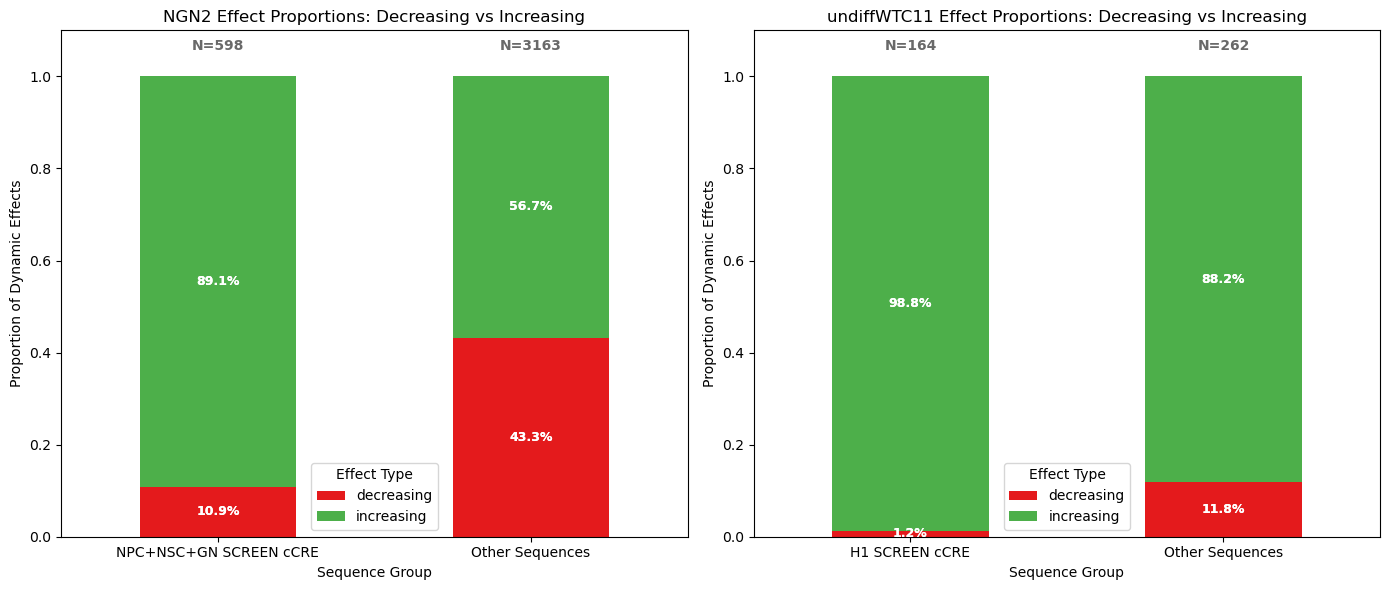

In [37]:
print("\n--- Visualizing 'increasing' vs 'decreasing' proportions with counts ---")
plt.figure(figsize=(14, 6))

# Define a consistent color palette for effect types
effect_colors = {
    'decreasing': sns.color_palette("Set1")[0],   # A red shade for decreasing (at bottom)
    'increasing': sns.color_palette("Set1")[2]  # A green shade for increasing (on top)
}

# Define the order of stacking for consistency: 'decreasing' at the bottom
effect_stack_order = ['decreasing', 'increasing']


# --- Plot 1: NGN2 Effect (increasing vs decreasing) ---
ax1_effect = plt.subplot(1, 2, 1)

plot_df_ngn2_effect = df_elements_ngn2_focus.copy()
plot_df_ngn2_effect['NPC_SCREEN_Group'] = plot_df_ngn2_effect['is_NPC_SCREEN_cCRE'].map({True: 'NPC SCREEN cCRE', False: 'Other Sequences'})
plot_df_ngn2_effect['NPC_NSC_GN_SCREEN_Group'] = plot_df_ngn2_effect['is_npc_or_excitatory_NSC_SCREEN_cre'].map({True: 'NPC+NSC+GN SCREEN cCRE', False: 'Other Sequences'})

# Filter out 'no_effect' before calculating proportions
filtered_ngn2_effects = plot_df_ngn2_effect[plot_df_ngn2_effect['bcalm_effect_NGN2'] != 'no_effect'].copy()

# Calculate proportions of 'increasing'/'decreasing'
proportions_ngn2_effect = filtered_ngn2_effects.groupby('NPC_NSC_GN_SCREEN_Group')['bcalm_effect_NGN2'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols_ngn2 = proportions_ngn2_effect.columns.tolist()
for col in effect_stack_order:
    if col not in current_cols_ngn2:
        proportions_ngn2_effect[col] = 0.0
proportions_ngn2_effect = proportions_ngn2_effect[effect_stack_order]


# Plotting
proportions_ngn2_effect.plot(kind='bar', stacked=True, ax=ax1_effect,
                             color=[effect_colors[col] for col in effect_stack_order])

ax1_effect.set_title('NGN2 Effect Proportions: Decreasing vs Increasing')
ax1_effect.set_xlabel('Sequence Group')
ax1_effect.set_ylabel('Proportion of Dynamic Effects')
ax1_effect.set_ylim(0, 1.1) # Adjusted y-limit to ensure N= annotation visibility
ax1_effect.tick_params(axis='x', rotation=0)
ax1_effect.legend(title='Effect Type')

# Annotate with the number of != "no_effect" (sum of 'increasing' and 'decreasing')
for i, group_label in enumerate(proportions_ngn2_effect.index):
    # Get the total count of 'increasing' + 'decreasing' for this group
    total_dynamic_effects = filtered_ngn2_effects[filtered_ngn2_effects['NPC_NSC_GN_SCREEN_Group'] == group_label].shape[0]

    # Position the count annotation above the top of the bar
    x_pos = i  # x-coordinate of the bar
    y_pos = 1.05 # Adjusted to be higher above the 100% mark

    ax1_effect.text(x_pos, y_pos, f'N={total_dynamic_effects}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

    # Add percentages within the bars
    for container in ax1_effect.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            if height > 0.01: # Only annotate if slice is large enough
                ax1_effect.text(x_val + width / 2, y_val + height / 2,
                                 f'{height:.1%}', ha='center', va='center', color='white', fontsize=9, # White for better contrast on colors
                                 fontweight='bold')



# --- Plot 2: undiffWTC11 Effect (increasing vs decreasing) ---
ax2_effect = plt.subplot(1, 2, 2)

plot_df_wtc11_effect = df_elements_wtc11_focus.copy()
plot_df_wtc11_effect['H1_SCREEN_Group'] = plot_df_wtc11_effect['is_H1_SCREEN_cCRE'].map({True: 'H1 SCREEN cCRE', False: 'Other Sequences'})

# Filter out 'no_effect' before calculating proportions
filtered_wtc11_effects = plot_df_wtc11_effect[plot_df_wtc11_effect['bcalm_effect_undiffWTC11'] != 'no_effect'].copy()

# Calculate proportions of 'increasing'/'decreasing'
proportions_wtc11_effect = filtered_wtc11_effects.groupby('H1_SCREEN_Group')['bcalm_effect_undiffWTC11'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols_wtc11 = proportions_wtc11_effect.columns.tolist()
for col in effect_stack_order:
    if col not in current_cols_wtc11:
        proportions_wtc11_effect[col] = 0.0
proportions_wtc11_effect = proportions_wtc11_effect[effect_stack_order]
print(proportions_wtc11_effect)

# Plotting
proportions_wtc11_effect.plot(kind='bar', stacked=True, ax=ax2_effect,
                              color=[effect_colors[col] for col in effect_stack_order])

ax2_effect.set_title('undiffWTC11 Effect Proportions: Decreasing vs Increasing')
ax2_effect.set_xlabel('Sequence Group')
ax2_effect.set_ylabel('Proportion of Dynamic Effects')
ax2_effect.set_ylim(0, 1.1) # Adjusted y-limit
ax2_effect.tick_params(axis='x', rotation=0)
ax2_effect.legend(title='Effect Type')

# Annotate with the number of != "no_effect" (sum of 'increasing' and 'decreasing')
for i, group_label in enumerate(proportions_wtc11_effect.index):
    total_dynamic_effects = filtered_wtc11_effects[filtered_wtc11_effects['H1_SCREEN_Group'] == group_label].shape[0]

    x_pos = i
    y_pos = 1.05

    ax2_effect.text(x_pos, y_pos, f'N={total_dynamic_effects}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

    # Add percentages within the bars
    for container in ax2_effect.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            if height > 0.01:
                ax2_effect.text(x_val + width / 2, y_val + height / 2,
                                 f'{height:.1%}', ha='center', va='center', color='white', fontsize=9,
                                 fontweight='bold')

plt.tight_layout()
plt.show()


--- Visualizing All Effect Proportions (Decreasing, Increasing, and No Effect) ---


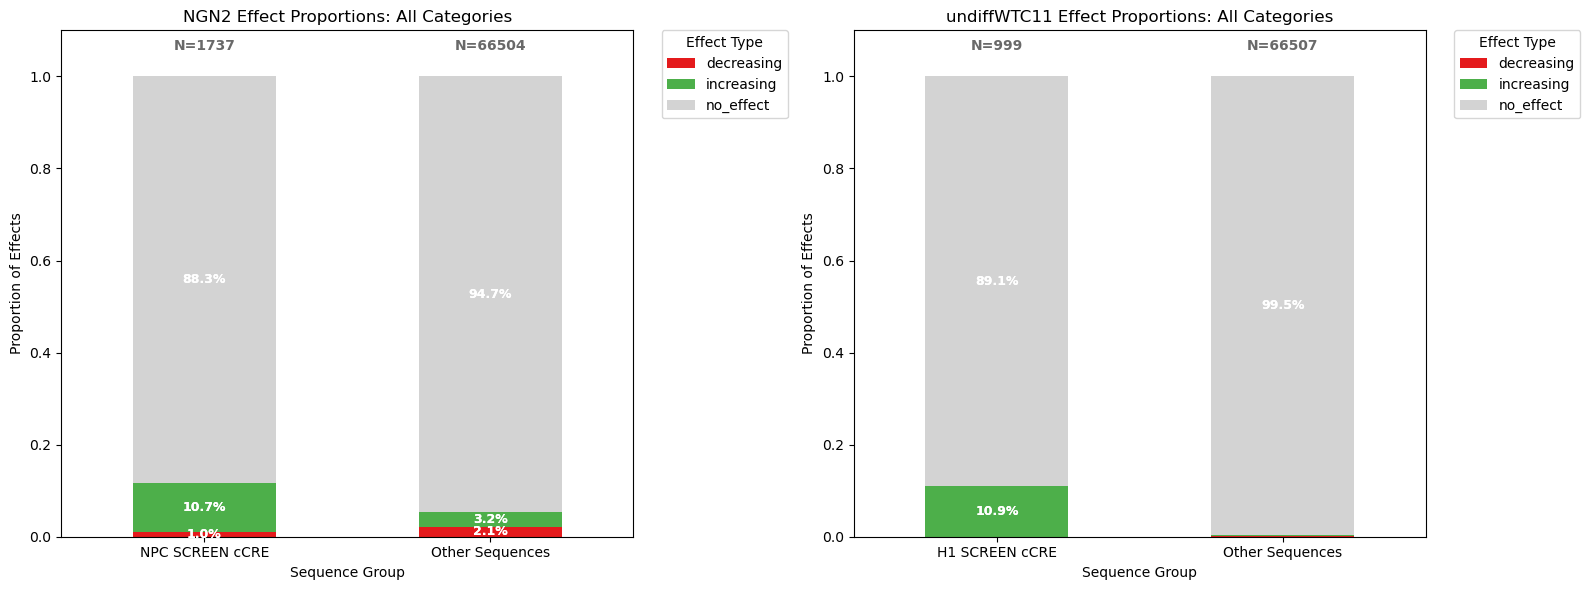

In [ ]:
print("\n--- Visualizing All Effect Proportions (Decreasing, Increasing, and No Effect) ---")

# Adjust figure size to accommodate external legend
plt.figure(figsize=(16, 6)) # Increased width

# Define a consistent color palette for all effect types
effect_colors = {
    'decreasing': sns.color_palette("Set1")[0],   # Red for decreasing
    'increasing': sns.color_palette("Set1")[2],  # Green for increasing
    'no_effect': 'lightgray'                     # Neutral color for no effect
}

# Define the order of stacking for consistency: 'decreasing' at bottom, then 'increasing', then 'no_effect'
effect_stack_order = ['decreasing', 'increasing', 'no_effect']


# --- Plot 1: NGN2 Effect (decreasing vs increasing vs no_effect) ---
ax1_effect = plt.subplot(1, 2, 1)

plot_df_ngn2_effect = df_elements_ngn2_focus.copy()
plot_df_ngn2_effect['NPC_SCREEN_Group'] = plot_df_ngn2_effect['is_NPC_SCREEN_cCRE'].map({True: 'NPC SCREEN cCRE', False: 'Other Sequences'})

# No filtering out 'no_effect' here - include all categories
# Calculate proportions of 'increasing'/'decreasing'/'no_effect'
proportions_ngn2_effect = plot_df_ngn2_effect.groupby('NPC_SCREEN_Group')['bcalm_effect_NGN2'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols_ngn2 = proportions_ngn2_effect.columns.tolist()
for col in effect_stack_order:
    if col not in current_cols_ngn2:
        proportions_ngn2_effect[col] = 0.0
proportions_ngn2_effect = proportions_ngn2_effect[effect_stack_order]


# Plotting
proportions_ngn2_effect.plot(kind='bar', stacked=True, ax=ax1_effect,
                             color=[effect_colors[col] for col in effect_stack_order])

ax1_effect.set_title('NGN2 Effect Proportions: All Categories')
ax1_effect.set_xlabel('Sequence Group')
ax1_effect.set_ylabel('Proportion of Effects')
ax1_effect.set_ylim(0, 1.1) # Adjusted y-limit to ensure N= annotation visibility
ax1_effect.tick_params(axis='x', rotation=0)

# Move legend outside for ax1
ax1_effect.legend(title='Effect Type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# Annotate with the total count for each group
for i, group_label in enumerate(proportions_ngn2_effect.index):
    # Get the total count for this group (including 'no_effect')
    total_elements_in_group = plot_df_ngn2_effect[plot_df_ngn2_effect['NPC_SCREEN_Group'] == group_label].shape[0]

    # Position the count annotation above the top of the bar
    x_pos = i  # x-coordinate of the bar
    y_pos = 1.05 # Adjusted to be higher above the 100% mark

    ax1_effect.text(x_pos, y_pos, f'N={total_elements_in_group}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

    # Add percentages within the bars
    for container in ax1_effect.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            # Only annotate if slice is large enough, and pick text color for contrast
            if height > 0.01:
                text_color = 'black' if patch.get_facecolor() == sns.color_palette("Set1")[2] or patch.get_facecolor() == 'lightgray' else 'white' # Adjust for light gray segment
                ax1_effect.text(x_val + width / 2, y_val + height / 2,
                                 f'{height:.1%}', ha='center', va='center', color=text_color, fontsize=9,
                                 fontweight='bold')


# --- Plot 2: undiffWTC11 Effect (decreasing vs increasing vs no_effect) ---
ax2_effect = plt.subplot(1, 2, 2)

plot_df_wtc11_effect = df_elements_wtc11_focus.copy()
plot_df_wtc11_effect['H1_SCREEN_Group'] = plot_df_wtc11_effect['is_H1_SCREEN_cCRE'].map({True: 'H1 SCREEN cCRE', False: 'Other Sequences'})

# No filtering out 'no_effect' here
# Calculate proportions of 'increasing'/'decreasing'/'no_effect'
proportions_wtc11_effect = plot_df_wtc11_effect.groupby('H1_SCREEN_Group')['bcalm_effect_undiffWTC11'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols_wtc11 = proportions_wtc11_effect.columns.tolist()
for col in effect_stack_order:
    if col not in current_cols_wtc11:
        proportions_wtc11_effect[col] = 0.0
proportions_wtc11_effect = proportions_wtc11_effect[effect_stack_order]


# Plotting
proportions_wtc11_effect.plot(kind='bar', stacked=True, ax=ax2_effect,
                              color=[effect_colors[col] for col in effect_stack_order])

ax2_effect.set_title('undiffWTC11 Effect Proportions: All Categories')
ax2_effect.set_xlabel('Sequence Group')
ax2_effect.set_ylabel('Proportion of Effects')
ax2_effect.set_ylim(0, 1.1) # Adjusted y-limit
ax2_effect.tick_params(axis='x', rotation=0)

# Move legend outside for ax2
ax2_effect.legend(title='Effect Type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# Annotate with the total count for each group
for i, group_label in enumerate(proportions_wtc11_effect.index):
    total_elements_in_group = plot_df_wtc11_effect[plot_df_wtc11_effect['H1_SCREEN_Group'] == group_label].shape[0]

    x_pos = i
    y_pos = 1.05

    ax2_effect.text(x_pos, y_pos, f'N={total_elements_in_group}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

    # Add percentages within the bars
    for container in ax2_effect.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            if height > 0.01:
                text_color = 'black' if patch.get_facecolor() == sns.color_palette("Set1")[2] or patch.get_facecolor() == 'lightgray' else 'white'
                ax2_effect.text(x_val + width / 2, y_val + height / 2,
                                 f'{height:.1%}', ha='center', va='center', color=text_color, fontsize=9,
                                 fontweight='bold')

plt.tight_layout() # This helps adjust spacing with external legends
plt.show()


--- Visualizing All Effect Proportions (Decreasing, Increasing, and No Effect) ---


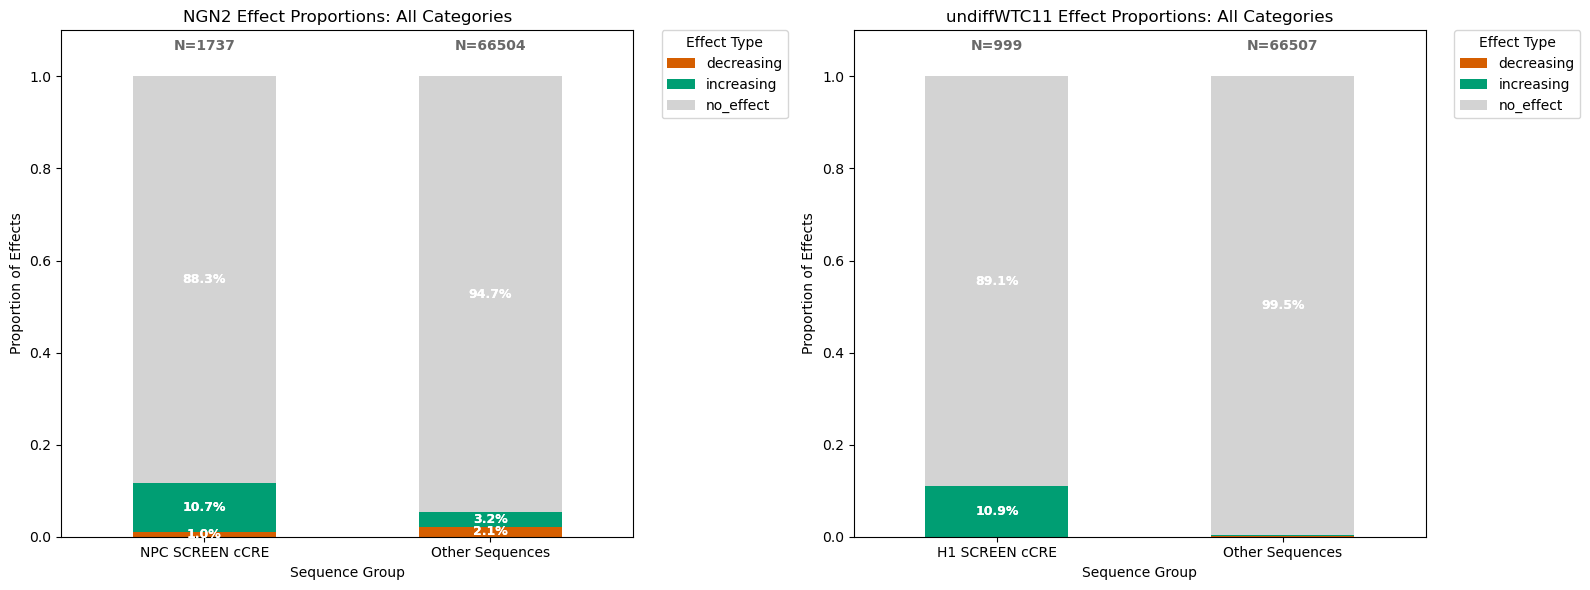

In [72]:
print("\n--- Visualizing All Effect Proportions (Decreasing, Increasing, and No Effect) ---")

# Adjust figure size to accommodate external legend
plt.figure(figsize=(16, 6)) # Increased width

# Define a consistent color palette for all effect types using colorblind-safe hex codes
effect_colors = {
    'decreasing': '#D55E00',   # Your specified blue for decreasing
    'increasing': '#009E73',  # Your specified orange for increasing
    'no_effect': 'lightgray'   # Neutral color for no effect
}

# Define the order of stacking for consistency: 'decreasing' at bottom, then 'increasing', then 'no_effect'
effect_stack_order = ['decreasing', 'increasing', 'no_effect']


# --- Plot 1: NGN2 Effect (decreasing vs increasing vs no_effect) ---
ax1_effect = plt.subplot(1, 2, 1)

plot_df_ngn2_effect = df_elements_ngn2_focus.copy()
plot_df_ngn2_effect['NPC_SCREEN_Group'] = plot_df_ngn2_effect['is_NPC_SCREEN_cCRE'].map({True: 'NPC SCREEN cCRE', False: 'Other Sequences'})

# No filtering out 'no_effect' here - include all categories
# Calculate proportions of 'increasing'/'decreasing'/'no_effect'
proportions_ngn2_effect = plot_df_ngn2_effect.groupby('NPC_SCREEN_Group')['bcalm_effect_NGN2'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols_ngn2 = proportions_ngn2_effect.columns.tolist()
for col in effect_stack_order:
    if col not in current_cols_ngn2:
        proportions_ngn2_effect[col] = 0.0
proportions_ngn2_effect = proportions_ngn2_effect[effect_stack_order]


# Plotting
proportions_ngn2_effect.plot(kind='bar', stacked=True, ax=ax1_effect,
                             color=[effect_colors[col] for col in effect_stack_order])

ax1_effect.set_title('NGN2 Effect Proportions: All Categories')
ax1_effect.set_xlabel('Sequence Group')
ax1_effect.set_ylabel('Proportion of Effects')
ax1_effect.set_ylim(0, 1.1) # Adjusted y-limit to ensure N= annotation visibility
ax1_effect.tick_params(axis='x', rotation=0)

# Move legend outside for ax1
ax1_effect.legend(title='Effect Type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# Annotate with the total count for each group
for i, group_label in enumerate(proportions_ngn2_effect.index):
    # Get the total count for this group (including 'no_effect')
    total_elements_in_group = plot_df_ngn2_effect[plot_df_ngn2_effect['NPC_SCREEN_Group'] == group_label].shape[0]

    # Position the count annotation above the top of the bar
    x_pos = i  # x-coordinate of the bar
    y_pos = 1.05 # Adjusted to be higher above the 100% mark

    ax1_effect.text(x_pos, y_pos, f'N={total_elements_in_group}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

    # Add percentages within the bars
    for container in ax1_effect.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            # Only annotate if slice is large enough, and pick text color for contrast
            if height > 0.01:
                # Use black text for light colors, white for dark colors
                text_color = 'black' if patch.get_facecolor() in ['#A9CDD9', 'lightgray'] else 'white'
                ax1_effect.text(x_val + width / 2, y_val + height / 2,
                                 f'{height:.1%}', ha='center', va='center', color=text_color, fontsize=9,
                                 fontweight='bold')


# --- Plot 2: undiffWTC11 Effect (decreasing vs increasing vs no_effect) ---
ax2_effect = plt.subplot(1, 2, 2)

plot_df_wtc11_effect = df_elements_wtc11_focus.copy()
plot_df_wtc11_effect['H1_SCREEN_Group'] = plot_df_wtc11_effect['is_H1_SCREEN_cCRE'].map({True: 'H1 SCREEN cCRE', False: 'Other Sequences'})

# No filtering out 'no_effect' here
# Calculate proportions of 'increasing'/'decreasing'/'no_effect'
proportions_wtc11_effect = plot_df_wtc11_effect.groupby('H1_SCREEN_Group')['bcalm_effect_undiffWTC11'].value_counts(normalize=True).unstack(fill_value=0)

# Ensure columns are in the desired stacking order and handle missing categories
current_cols_wtc11 = proportions_wtc11_effect.columns.tolist()
for col in effect_stack_order:
    if col not in current_cols_wtc11:
        proportions_wtc11_effect[col] = 0.0
proportions_wtc11_effect = proportions_wtc11_effect[effect_stack_order]


# Plotting
proportions_wtc11_effect.plot(kind='bar', stacked=True, ax=ax2_effect,
                              color=[effect_colors[col] for col in effect_stack_order])

ax2_effect.set_title('undiffWTC11 Effect Proportions: All Categories')
ax2_effect.set_xlabel('Sequence Group')
ax2_effect.set_ylabel('Proportion of Effects')
ax2_effect.set_ylim(0, 1.1) # Adjusted y-limit
ax2_effect.tick_params(axis='x', rotation=0)

# Move legend outside for ax2
ax2_effect.legend(title='Effect Type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# Annotate with the total count for each group
for i, group_label in enumerate(proportions_wtc11_effect.index):
    total_elements_in_group = plot_df_wtc11_effect[plot_df_wtc11_effect['H1_SCREEN_Group'] == group_label].shape[0]

    x_pos = i
    y_pos = 1.05

    ax2_effect.text(x_pos, y_pos, f'N={total_elements_in_group}',
                    ha='center', va='bottom', fontsize=10, color='dimgray', weight='bold')

    # Add percentages within the bars
    for container in ax2_effect.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x_val = patch.get_x()
            y_val = patch.get_y()
            if height > 0.01:
                # Use black text for light colors, white for dark colors
                text_color = 'black' if patch.get_facecolor() in ['#A9CDD9', 'lightgray'] else 'white'
                ax2_effect.text(x_val + width / 2, y_val + height / 2,
                                 f'{height:.1%}', ha='center', va='center', color=text_color, fontsize=9,
                                 fontweight='bold')

plt.tight_layout() # This helps adjust spacing with external legends
plt.show()

#### Write to file

In [73]:
asdf

NameError: name 'asdf' is not defined

In [57]:
writing = False
if writing:
    # df_elements.to_csv('/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_elements_bcalm_scrambled095_2506.tsv.gz', sep='\t', index=False)
    # df_elements.to_csv('/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_elements_bcalm_scrambled095_2507.tsv.gz', sep='\t', index=False)
    # df_elements.to_csv('/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_elements_bcalm_scrambled095_screenv4_2507.tsv.gz', sep='\t', index=False)
    # df_elements.to_csv('/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_elements_bcalm_scrambled095_screenv4_2507_ngn2_neuro_ctrl.tsv.gz', sep='\t', index=False)
    df_elements.to_csv('/home/kisa/coding/80K_MPRA/element_variant_analysis_output/ngn2_wtc11_elements_bcalm_scrambled095_screenv4_annotation_groups_2507_ngn2_neuro_ctrl.tsv.gz', sep='\t', index=False)

#### Classify the elements based on the bcalm results and identify the elements which are not active in both cell types as background set
- Number of oligos measured in both cell-types: 67,451

In [ ]:
df_elements_both_cell_types = df_elements.loc[df_elements['measured_in_both_celltypes']].copy()
df_elements_both_cell_types

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_WTC11_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,EH38E1825144,False,False,False,False,True,False,decreasing,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,EH38E1825170,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,EH38E1825171,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,EH38E3188739,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149.0,70277419.0,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,EH38E3188758,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,EH38E3899597,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116.0,107008386.0,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,EH38E3899600,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,EH38E3899604,False,False,False,False,False,False,no_effect,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939.0,107039209.0,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,EH38E3899614,False,False,False,False,False,False,no_effect,no_effect,True


IDEA: We would like to investigate the sequence based differences of sequences which were measured with high activity in one cell-type but are not active in the other cell-type. What is the difference? 
There are three groups of sequences 

### Investigate the barcode output from MPRAsnakeflow on the 80k dataset (undiff looks odd)

In [58]:
# load barcode table for undiff
barcode_table_undiffWTC11_path = "/data/cephfs-2/unmirrored/groups/kircher/IGVF_data_submssion_TM/80K/mprasnakeflow/results/experiments/defaultWTC11Resequencing/assigned_counts/defaultAssignmentBBMap/default/WTC11_allreps_merged.tsv.gz"
barcode_table_undiffWTC11 = pd.read_csv(barcode_table_undiffWTC11_path, sep='\t')
barcode_table_undiffWTC11

,replicate,oligo_name,dna_counts,rna_counts,dna_normalized,rna_normalized,log2FoldChange,n_bc
0,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,941,1938,0.3413,0.3216,-0.0857,87
1,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,869,2291,0.3265,0.3938,0.2706,84
2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,493,1040,0.2829,0.2730,-0.0511,55
3,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,770,1710,0.2928,0.2975,0.0231,83
4,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,370,1002,0.2595,0.3215,0.3093,45
...,...,...,...,...,...,...,...,...
232627,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,66,40,0.2020,0.0444,-2.1848,11
232628,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,404,1095,0.2061,0.2027,-0.0239,66
232629,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,217,515,0.2922,0.2517,-0.2155,25
232630,3,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,226,355,0.2818,0.1606,-0.8109,27


In [59]:
undiffWTC11_barcode_table_path = "/home/kisa/coding/80K_MPRA/ismb/undiff_WTC11/renamed_reporter_experiment.barcode.WTC11.defaultAssignment.default.all.tsv.gz"
barcode_table_undiffWTC11 = pd.read_csv(undiffWTC11_barcode_table_path, sep='\t')
barcode_table_undiffWTC11

,barcode,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3
0,AACCGTGCACGTTTG,GC_DNase_negative_blood:chr10:16877280-1687754...,NaN,NaN,NaN,NaN,2.0,3.0
1,CCGTACGCTCGACCT,GC_DNase_negative_blood:chr10:16877280-1687754...,2.0,1.0,NaN,NaN,NaN,NaN
2,GGCCTTAACCGTACA,GC_DNase_negative_blood:chr10:16877280-1687754...,3.0,13.0,4.0,7.0,1.0,20.0
3,GGCAAACCAGAGAAG,GC_DNase_negative_blood:chr10:16877280-1687754...,NaN,NaN,1.0,6.0,5.0,14.0
4,CTTGGTTGCGTGTAC,GC_DNase_negative_blood:chr10:16877280-1687754...,3.0,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
5031007,GATGCCAATATATAT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,1.0,1.0,NaN,NaN,NaN,NaN
5031008,TTGCCAAGCGGTACT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,9.0,4.0,5.0,21.0
5031009,CGTAAATGTATGCGT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,1.0,1.0,3.0,1.0
5031010,GGGATGATTTCTGGG,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,1.0,8.0,2.0,3.0,11.0,14.0


In [60]:

NGN2_barcode_table_path = "/home/kisa/coding/80K_MPRA/ismb/NGN2_neurons/renamed_reporter_experiment.barcode.NGN2.defaultAssignment.default.all.tsv.gz"
barcode_table_NGN2 = pd.read_csv(NGN2_barcode_table_path, sep='\t')
barcode_table_NGN2

,barcode,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3
0,TTGTTAAAGGGGAGG,GC_DNase_negative_blood:chr10:16877280-1687754...,1.0,8.0,3.0,1.0,2.0,2.0
1,GTTCGTCTAAGTTTG,GC_DNase_negative_blood:chr10:16877280-1687754...,13.0,20.0,4.0,22.0,3.0,32.0
2,GACGCCCAGCCGCTG,GC_DNase_negative_blood:chr10:16877280-1687754...,2.0,8.0,2.0,2.0,1.0,6.0
3,TGTCGTCTCCGCTCG,GC_DNase_negative_blood:chr10:16877280-1687754...,1.0,7.0,3.0,11.0,4.0,8.0
4,TCGCGCATCACGACG,GC_DNase_negative_blood:chr10:16877280-1687754...,4.0,14.0,1.0,8.0,6.0,9.0
...,...,...,...,...,...,...,...,...
6370543,GGGGATGCGGTAGGA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,7.0,13.0,6.0,17.0,6.0,10.0
6370544,ATGTAAAGACCCCCC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,4.0,20.0,7.0,24.0,7.0,18.0
6370545,GATCGACGTTTTTAA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,1.0,14.0,5.0,15.0,4.0,9.0
6370546,ACTATGTTATCCAAC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,4.0,10.0,2.0,5.0


- DNA: 
- only half of the DNA counts are observed in the undiff WTC11:
- One reason: the proportion of barcodes observed in a replicate is only around 60% and for NGN2 this proportion is over 85%. The second reason is we observe 1 million barcodes less in undiffWTC11 

In [66]:
# what is the overall dna count?
dna_columns = ['dna_count_1', 'dna_count_2', 'dna_count_3']
barcode_table_NGN2.columns
dna_sum = 0
for col in dna_columns:
    print(col, ": ", barcode_table_NGN2[col].sum())
    dna_sum += barcode_table_NGN2[col].sum()
    # how many are not na:
    print("not na: ", barcode_table_NGN2[col].notna().sum() / barcode_table_NGN2.shape[0])
print(dna_sum)


dna_count_1 :  20009997.0
not na:  0.8554502689564539
dna_count_2 :  20659305.0
not na:  0.8569509247870042
dna_count_3 :  20932364.0
not na:  0.862655614556236
61601666.0


In [67]:
# what is the overall dna count?
dna_columns = ['dna_count_1', 'dna_count_2', 'dna_count_3']
barcode_table_undiffWTC11.columns
dna_sum = 0
for col in dna_columns:
    print(col, ": ", barcode_table_undiffWTC11[col].sum())
    dna_sum += barcode_table_undiffWTC11[col].sum()
    # how many are not na:
    print("not na: ", barcode_table_undiffWTC11[col].notna().sum() / barcode_table_undiffWTC11.shape[0])
print(dna_sum)

dna_count_1 :  11769671.0
not na:  0.5963325072569893
dna_count_2 :  12623573.0
not na:  0.6087441254363933
dna_count_3 :  11546449.0
not na:  0.6436353163140934
35939693.0


In [68]:
# how many are still existing if I look into barcodes which are occuring in at least 2 replicates?
barcode_table_undiffWTC11['dna_in_two_cell_types'] = barcode_table_undiffWTC11['dna_count_1'].notna() + barcode_table_undiffWTC11['dna_count_2'].notna() + barcode_table_undiffWTC11['dna_count_3'].notna() >= 2
barcode_table_undiffWTC11['dna_in_two_cell_types'].sum()

0

In [ ]:
barcode_table_undiffWTC11['dna_na_count'] = barcode_table_undiffWTC11[dna_columns].count(axis=1)
barcode_table_undiffWTC11['dna_na_count']


In [74]:
filtered_barcode_table_undiffWTC11 = barcode_table_undiffWTC11[barcode_table_undiffWTC11['dna_na_count'] >= 2].drop(columns=['dna_na_count'])

In [75]:
filtered_barcode_table_undiffWTC11

,barcode,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,dna_in_two_cell_types
2,GGCCTTAACCGTACA,GC_DNase_negative_blood:chr10:16877280-1687754...,3.0,13.0,4.0,7.0,1.0,20.0,False
3,GGCAAACCAGAGAAG,GC_DNase_negative_blood:chr10:16877280-1687754...,NaN,NaN,1.0,6.0,5.0,14.0,False
5,AGGTTACCATATACC,GC_DNase_negative_blood:chr10:16877280-1687754...,4.0,8.0,8.0,23.0,6.0,24.0,False
6,GTGAAACCGGCTGGA,GC_DNase_negative_blood:chr10:16877280-1687754...,NaN,NaN,7.0,10.0,1.0,1.0,False
8,AACACTGGAATAATT,GC_DNase_negative_blood:chr10:16877280-1687754...,3.0,17.0,7.0,15.0,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...
5031006,CAGGCCCCTGGACGT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3.0,8.0,10.0,6.0,2.0,6.0,False
5031008,TTGCCAAGCGGTACT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,9.0,4.0,5.0,21.0,False
5031009,CGTAAATGTATGCGT,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,1.0,1.0,3.0,1.0,False
5031010,GGGATGATTTCTGGG,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,1.0,8.0,2.0,3.0,11.0,14.0,False


In [77]:
# what is the overall dna count?
dna_columns = ['dna_count_1', 'dna_count_2', 'dna_count_3']
filtered_barcode_table_undiffWTC11.columns
dna_sum = 0
for col in dna_columns:
    print(col, ": ", filtered_barcode_table_undiffWTC11[col].sum())
    dna_sum += filtered_barcode_table_undiffWTC11[col].sum()
    # how many are not na:
    print("not na: ", filtered_barcode_table_undiffWTC11[col].notna().sum() / filtered_barcode_table_undiffWTC11.shape[0])
print(dna_sum)

dna_count_1 :  9837140.0
not na:  0.782555608260762
dna_count_2 :  10490245.0
not na:  0.7925126424389078
dna_count_3 :  9458207.0
not na:  0.8207995376180596
29785592.0


In [ ]:
undiffWTC11_barcode_table_out_path = "/home/kisa/coding/80K_MPRA/ismb/undiff_WTC11/renamed_reporter_experiment.barcode.WTC11.downfiltering.defaultAssignment.default.all.tsv.gz"


0

### Compare for each cell-type the scrambled and tested data

### AI assistant:

I have tested ~26,000 different genomic regions called candidate regulatory regions (not cell-type specific) as well as a set of variants within these regions. We will focus for this analysis only on the regions and ignore the variants. We have tested these genomics regions in two cell-types as well as the same scrambled sequences which can be used to "normalize" the measured element activities.
1. I would like to investigate and show the distribution of the scrambled and the tested elements within each cell-type
2. I would like to normalize the element activities and plot the difference of cell-type specific CREs vs the elements which are not considered CREs (this comparison might be inbalanced) but I would like to test if the mean of the CRE group is significantly higher compared to the non-CRE group. This comparison and statistical test need to deal with a highly inbalanced set. The same thing with a different annotation: overlap with open-chromatin within this specific cell-type. The groupsizes should be reportet in the respective plot as well.
3. With the normalized data and a modified t-test within a statistical tool called BCalm it is possible to assess if the element's activity is "increasing" or "decreasing". I would like to compare these class distributions considering again cell-type specific CRE and not-CRE groups (or open-chromatin and not-open-chromatin groups).
4. Compare the overlap between "increasing", "decreasing" and "no effect elements" between these two cell-types, remember not every element needs to have a measurement within both cell-types.
5. Overlap the elements with regulatory effect and test if they are enriched for chip-seq peaks (using ReMap2022) and as background set use the elements which have measurments within both experiments, but a normalized activity close to zero as well as "no effect".

Question:
How would you organize the data to make these analysis as easy as possible in python?
Which statistical test would you perform for 2.?
Which statistical test would you perform for 5.?

### Datastructure:

| Column Name                           | Data Type      | Description                                                                                                                                                 |
|---------------------------------------|----------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------|
| name                                  | str            | Unique identifier for each genomic region (originally region_id).                                                                                           |
| chr                                   | str            | Chromosome (e.g., 'chr1', 'chrX').                                                                                                                          |
| start                                 | int            | Start coordinate of the region.                                                                                                                             |
| end                                   | int            | End coordinate of the region.                                                                                                                               |
| strand                                | str            | Strand of the region ('+' or '-').                                                                                                                          |
| sequence                              | str            | The DNA sequence of the region (important for identifying scrambled).                                                                                       |
| label                                 | str            | Original classification from input (e.g., 'scrambled', 'candidate_region', 'variant'). This is essential for distinguishing scrambled controls.             |
| raw_activity_NGN2_log2FC_bcalm        | float          | Raw log2 fold change activity from BCalm in NGN2. (Corresponds to bcalm_element_log_ratio_activity from your input file)                                    |
| raw_activity_undiffWTC11_log2FC_bcalm | float          | Raw log2 fold change activity from BCalm in undiffWTC11. (Corresponds to bcalm_element_log_ratio_activity from your input file)                             |
| normalized_activity_NGN2              | float          | Activity in NGN2, normalized by your specified method (median and std dev of scrambled controls in NGN2).                                                   |
| normalized_activity_undiffWTC11       | float          | Activity in undiffWTC11, normalized by your specified method (median and std dev of scrambled controls in undiffWTC11).                                     |
| is_CRE_NGN2                           | bool           | True if element meets CRE criteria in NGN2 (e.g., significant p-value from BCalm, and positive activity).                                                   |
| is_CRE_undiffWTC11                    | bool           | True if element meets CRE criteria in undiffWTC11.                                                                                                          |
| overlaps_open_chromatin_NGN2          | bool           | True if element overlaps open chromatin in NGN2, False otherwise.                                                                                           |
| overlaps_open_chromatin_undiffWTC11   | bool           | True if element overlaps open chromatin in undiffWTC11, False otherwise.                                                                                    |
| bcalm_effect_NGN2                     | category (str) | BCalm classification for NGN2: 'increasing', 'decreasing', 'no_effect'. (Derived from bcalm_element_adjusted_p_value and bcalm_element_log_ratio_activity). |
| bcalm_effect_undiffWTC11              | category (str) | BCalm classification for undiffWTC11: 'increasing', 'decreasing', 'no_effect'.                                                                              |
| overlaps_remap_TFactor1               | bool           | True if overlaps TF1 peak from ReMap2022, False otherwise. (Repeat for all TFs/marks of interest).                                                          |
| measured_in_both_celltypes            | bool           | True if activity measurements exist for this element in both NGN2 and undiffWTC11, False otherwise.                                                         |
| is_background_q5                      | bool           | True if element qualifies for the background set for Q5, False otherwise.                                                                                   |

### Second try: 
You are a bioinformatician with specific knownledge in analyzing genomic data within and between cell-types using python. You want to generate a descriptive investigation of a given dataset and provide insights into statistical testing for enrichments and answer general questions as well as providing code for this purpose.


Imagine there is a dataframe with the following columns:

['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label', 'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2', 'normalized_activity_NGN2', 'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11', 'normalized_activity_undiffWTC11', 'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE', 'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2', 'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11', 'measured_in_both_celltypes']

All columns with "is_*" are boolean columns.


It contains activity information of the same sequences (given by "name") within two cell-types.

Now I would like to investigate the following questions with statistical approaches which handle inbalanced data well.


1. Is the activity distribution ("raw_activity_NGN2_log2FC_bcalm") of the group defined by "is_NPC_SCREEN_cCRE" compared to the other sequences significantly higher?

2. Is the activity distribution ("raw_activity_undiffWTC11_log2FC_bcalm") of the group defined by "is_H1_SCREEN_cCRE" compared to the other sequences significantly higher?

3. Visualize the results of the results from 1 and 2 appropriately

4. Is the number of "is_dCRE_WTC11" enriched in the group defined by "is_H1_SCREEN_cCRE" compared to the other sequences?

5. Is the number of "is_dCRE_NGN2" enriched in the group defined by "is_NPC_SCREEN_cCRE" compared to the other sequences? 